In [2]:
import pandas as pd 
import numpy as np


%matplotlib inline
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier
from sklearn import tree


from sklearn.model_selection import train_test_split
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import StandardScaler 
from sklearn import metrics

In [3]:
data = pd.read_csv('heart_2020_cleaned.csv')
data.head(6)


,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,Yes,No,No,3.0,30.0,No,Female,55-59,White,Yes,Yes,Very good,5.0,Yes,No,Yes
1,No,20.34,No,No,Yes,0.0,0.0,No,Female,80 or older,White,No,Yes,Very good,7.0,No,No,No
2,No,26.58,Yes,No,No,20.0,30.0,No,Male,65-69,White,Yes,Yes,Fair,8.0,Yes,No,No
3,No,24.21,No,No,No,0.0,0.0,No,Female,75-79,White,No,No,Good,6.0,No,No,Yes
4,No,23.71,No,No,No,28.0,0.0,Yes,Female,40-44,White,No,Yes,Very good,8.0,No,No,No
5,Yes,28.87,Yes,No,No,6.0,0.0,Yes,Female,75-79,Black,No,No,Fair,12.0,No,No,No


In [4]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 1. Load the dataset
data = pd.read_csv('heart_2020_cleaned.csv')

# 2. Clean binary 'Yes' / 'No' columns to 1 and 0 (integers, NOT strings!)
binary_cols = [
    'HeartDisease', 'Smoking', 'AlcoholDrinking', 'Stroke', 
    'DiffWalking', 'PhysicalActivity', 'Asthma', 'KidneyDisease', 'SkinCancer'
]
for col in binary_cols:
    data[col] = data[col].map({'Yes': 1, 'No': 0})

# 3. Clean 'Sex' and 'Diabetic' columns
data['Sex'] = data['Sex'].map({'Male': 1, 'Female': 0})
data['Diabetic'] = data['Diabetic'].replace({
    'Yes': 1, 
    'Yes (during pregnancy)': 1, 
    'No': 0, 
    'No, borderline diabetes': 0
})

# 4. Ordinal encoding for AgeCategory and GenHealth (preserves true ranking!)
label_encoder = LabelEncoder()
data['AgeCategory'] = label_encoder.fit_transform(data['AgeCategory'])
data['GenHealth'] = label_encoder.fit_transform(data['GenHealth'])

# 5. One-hot encode ONLY 'Race' to avoid artificial ranking (adds just 5 columns)
data = pd.get_dummies(data, columns=['Race'], drop_first=True)

# 6. Separate features (X) and target (y)
X = data.drop('HeartDisease', axis=1)
y = data['HeartDisease']

# 7. Scale all features using StandardScaler (exactly like in puma.ipynb)
scaler = StandardScaler()
X_scaled_values = scaler.fit_transform(X)

# 8. Create the clean data_scaled DataFrame
data_scaled = pd.DataFrame(X_scaled_values, columns=X.columns)
data_scaled['HeartDisease'] = y.values  # Add target back as unscaled 0/1 integers

print("Data cleaning and scaling complete. Shape:", data_scaled.shape)
data_scaled.info()
data_scaled.head(30)

Data cleaning and scaling complete. Shape: (319795, 22)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319795 entries, 0 to 319794
Data columns (total 22 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   BMI               319795 non-null  float64
 1   Smoking           319795 non-null  float64
 2   AlcoholDrinking   319795 non-null  float64
 3   Stroke            319795 non-null  float64
 4   PhysicalHealth    319795 non-null  float64
 5   MentalHealth      319795 non-null  float64
 6   DiffWalking       319795 non-null  float64
 7   Sex               319795 non-null  float64
 8   AgeCategory       319795 non-null  float64
 9   Diabetic          319795 non-null  float64
 10  PhysicalActivity  319795 non-null  float64
 11  GenHealth         319795 non-null  float64
 12  SleepTime         319795 non-null  float64
 13  Asthma            319795 non-null  float64
 14  KidneyDisease     319795 non-null  float64
 15  SkinCancer  

,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Diabetic,...,SleepTime,Asthma,KidneyDisease,SkinCancer,Race_Asian,Race_Black,Race_Hispanic,Race_Other,Race_White,HeartDisease
0,-1.844750,1.193474,-0.27032,-0.198040,-0.046751,3.281069,-0.401578,-0.951711,0.136184,2.524911,...,-1.460354,2.541515,-0.195554,3.118419,-0.160878,-0.277980,-0.3064,-0.188098,0.551505,0
1,-1.256338,-0.837890,-0.27032,5.049478,-0.424070,-0.490039,-0.401578,-0.951711,1.538806,-0.396054,...,-0.067601,-0.393466,-0.195554,-0.320675,-0.160878,-0.277980,-0.3064,-0.188098,0.551505,0
2,-0.274603,1.193474,-0.27032,-0.198040,2.091388,3.281069,-0.401578,1.050739,0.697233,2.524911,...,0.628776,2.541515,-0.195554,-0.320675,-0.160878,-0.277980,-0.3064,-0.188098,0.551505,0
3,-0.647473,-0.837890,-0.27032,-0.198040,-0.424070,-0.490039,-0.401578,-0.951711,1.258282,-0.396054,...,-0.763977,-0.393466,-0.195554,3.118419,-0.160878,-0.277980,-0.3064,-0.188098,0.551505,0
4,-0.726138,-0.837890,-0.27032,-0.198040,3.097572,-0.490039,2.490174,-0.951711,-0.705388,-0.396054,...,0.628776,-0.393466,-0.195554,-0.320675,-0.160878,-0.277980,-0.3064,-0.188098,0.551505,0
5,0.085682,1.193474,-0.27032,-0.198040,0.330568,-0.490039,2.490174,-0.951711,1.258282,-0.396054,...,3.414282,-0.393466,-0.195554,-0.320675,-0.160878,3.597375,-0.3064,-0.188098,-1.813222,1
6,-1.053383,-0.837890,-0.27032,-0.198040,1.462524,-0.490039,-0.401578,-0.951711,0.977757,-0.396054,...,-2.156730,2.541515,-0.195554,3.118419,-0.160878,-0.277980,-0.3064,-0.188098,0.551505,0
7,0.521484,1.193474,-0.27032,-0.198040,0.204795,-0.490039,2.490174,-0.951711,1.538806,2.524911,...,1.325152,2.541515,-0.195554,-0.320675,-0.160878,-0.277980,-0.3064,-0.188098,0.551505,0
8,-0.295055,-0.837890,-0.27032,-0.198040,-0.424070,-0.490039,-0.401578,-0.951711,1.538806,-0.396054,...,-1.460354,-0.393466,5.113667,-0.320675,-0.160878,-0.277980,-0.3064,-0.188098,0.551505,0
9,1.945316,-0.837890,-0.27032,-0.198040,-0.424070,-0.490039,2.490174,1.050739,0.697233,-0.396054,...,2.021529,-0.393466,-0.195554,-0.320675,-0.160878,-0.277980,-0.3064,-0.188098,0.551505,0


<ipython-input-4-4a95d7cd2fef>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='HeartDisease', data=data_scaled, palette='Set2')


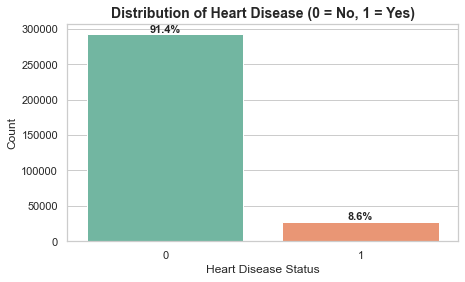

In [4]:

# Set figure style
sns.set_theme(style="whitegrid")

# Distribution of Heart Disease
plt.figure(figsize=(7, 4))
ax = sns.countplot(x='HeartDisease', data=data_scaled, palette='Set2')
plt.title('Distribution of Heart Disease (0 = No, 1 = Yes)', fontsize=14, fontweight='bold')
plt.xlabel('Heart Disease Status', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Add percentage labels on top of bars
total = len(data_scaled)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.show()


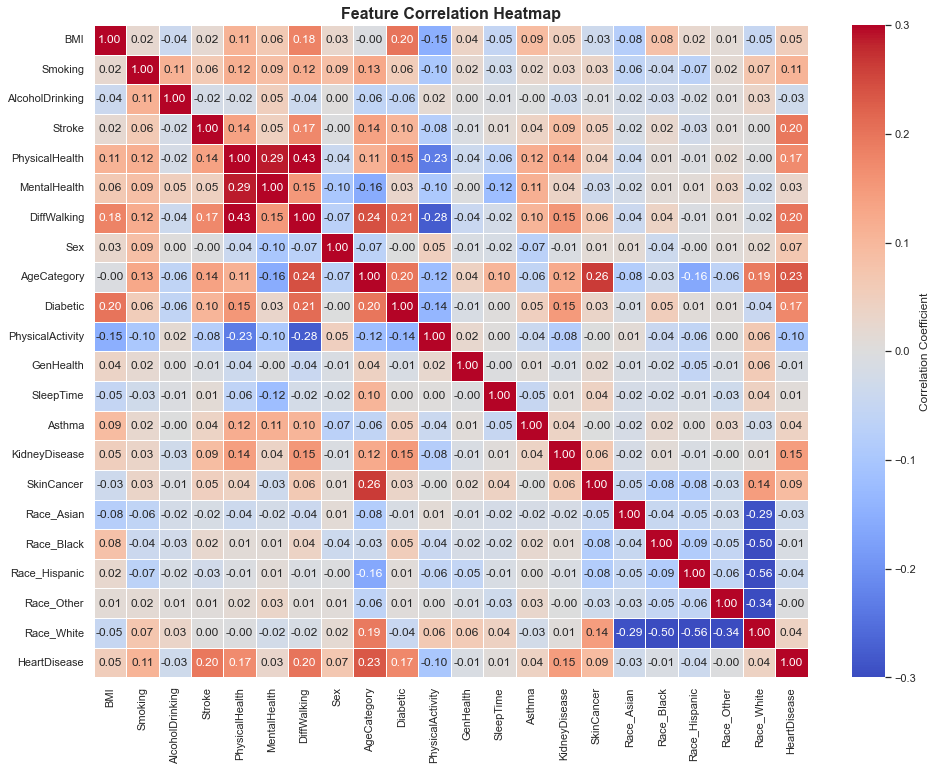

In [5]:

# Correlation Heatmap
plt.figure(figsize=(16, 12))
corr = data_scaled.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-0.3, vmax=0.3, 
            cbar_kws={'label': 'Correlation Coefficient'}, linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.show()

In [6]:
import time
from sklearn import svm

# Baseline SVM Run with Timing
print("Running baseline SVM...")

# Split the scaled data
X_train, X_test, y_train, y_test = train_test_split(X_scaled_values, y, test_size=0.2, random_state=42)

start_time = time.time()

# Initialize and train the model (using default parameters)
clf = svm.SVC(kernel='linear', C=0.65)
clf.fit(X_train, y_train)

# Predict
y_pred = clf.predict(X_test)

end_time = time.time()
execution_time = end_time - start_time

accuracy = metrics.accuracy_score(y_test, y_pred)
recall = metrics.recall_score(y_test, y_pred)

print(f"--- SVM Execution Results ---")
print(f"Time taken: {execution_time:.6f} seconds")
print(f"Accuracy: {accuracy*100:.2f}%")
print(f"Recall: {recall*100:.2f}%")

Running baseline SVM...
--- SVM Execution Results ---
Time taken: 1105.925538 seconds
Accuracy: 91.36%
Recall: 0.00%


In [7]:
import time
from sklearn import svm

# Baseline SVM Run with Timing
print("Running baseline SVM...")

# Split the scaled data
X_train, X_test, y_train, y_test = train_test_split(X_scaled_values, y, test_size=0.2, random_state=42)

start_time = time.time()

# Initialize and train the model (using default parameters)
clf = svm.SVC(kernel='linear',class_weight='balanced', C=0.65)
clf.fit(X_train, y_train)

# Predict
y_pred = clf.predict(X_test)

end_time = time.time()
execution_time = end_time - start_time

accuracy = metrics.accuracy_score(y_test, y_pred)
recall = metrics.recall_score(y_test, y_pred)

print(f"--- SVM Execution Results ---")
print(f"Time taken: {execution_time:.6f} seconds")
print(f"Accuracy: {accuracy*100:.2f}%")
print(f"Recall: {recall*100:.2f}%")

Running baseline SVM...
--- SVM Execution Results ---
Time taken: 4650.960603 seconds
Accuracy: 72.91%
Recall: 78.29%


Running SDG classifier instead of SVM...
Time taken: 1.56 seconds
--------------------------------------------------
Accuracy:  71.62%  (Overall correctness)
Recall:    78.01%  (Ability to catch ALL Heart Disease cases)
Precision: 20.13%  (Accuracy when predicting Heart Disease)
F1-Score:  32.00%  (Balance of Recall and Precision)


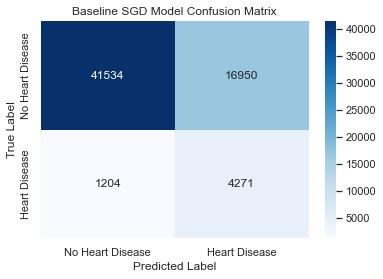

In [8]:

from sklearn.linear_model import SGDClassifier

print("Running SDG classifier instead of SVM...")

# 1. Split the scaled 300k dataset (70% Train, 30% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_values, y, test_size=0.2, random_state=42, stratify=y
)

start_time = time.time()

# 2. Initialize and train the SGD Classifier (Linear SVM with Hinge Loss + L2 Regularization)
clf = SGDClassifier(
    loss='hinge',             # Linear SVM objective (Hinge Loss)
    penalty='l2',             # Standard L2 margin penalty
    alpha=0.0001,             # Regularization strength
    class_weight='balanced',  # Crucial for the 91% / 9% class imbalance
    max_iter=1000,
    random_state=42
)
clf.fit(X_train, y_train)

# 3. Predict on the 20% holdout test set
y_pred = clf.predict(X_test)

end_time = time.time()
execution_time = end_time - start_time

# 4. Calculate metrics
acc  = metrics.accuracy_score(y_test, y_pred)
rec  = metrics.recall_score(y_test, y_pred)
prec = metrics.precision_score(y_test, y_pred)
f1   = metrics.f1_score(y_test, y_pred)

# 5. Generate the Medical Performance Report
print(f"Time taken: {execution_time:.2f} seconds")
print("-" * 50)
print(f"Accuracy:  {acc*100:.2f}%  (Overall correctness)")
print(f"Recall:    {rec*100:.2f}%  (Ability to catch ALL Heart Disease cases)")
print(f"Precision: {prec*100:.2f}%  (Accuracy when predicting Heart Disease)")
print(f"F1-Score:  {f1*100:.2f}%  (Balance of Recall and Precision)")

# 6. Plot Confusion Matrix
cm = metrics.confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Heart Disease', 'Heart Disease'],
            yticklabels=['No Heart Disease', 'Heart Disease'])
plt.title('Baseline SGD Model Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

Starting Advanced Medical Puma Optimization with Intelligent Phase Change...
Cycle 01: Phase=BOTH    | CV Recall=82.63%, CV Acc=64.73%, Features=11, Alpha=0.100000
Cycle 02: Phase=BOTH    | CV Recall=82.63%, CV Acc=64.92%, Features=11, Alpha=0.100000
Cycle 03: Phase=BOTH    | CV Recall=82.87%, CV Acc=64.65%, Features=10, Alpha=0.100000
Cycle 04: Phase=EXPLORE | CV Recall=82.87%, CV Acc=64.65%, Features=10, Alpha=0.100000
Cycle 05: Phase=EXPLOIT | CV Recall=82.87%, CV Acc=64.65%, Features=10, Alpha=0.100000
Cycle 06: Phase=EXPLOIT | CV Recall=82.87%, CV Acc=64.65%, Features=10, Alpha=0.100000
Cycle 07: Phase=EXPLORE | CV Recall=82.87%, CV Acc=64.65%, Features=10, Alpha=0.100000
Cycle 08: Phase=EXPLORE | CV Recall=82.87%, CV Acc=64.65%, Features=10, Alpha=0.100000
Cycle 09: Phase=EXPLOIT | CV Recall=82.87%, CV Acc=64.65%, Features=10, Alpha=0.100000
Cycle 10: Phase=EXPLORE | CV Recall=82.87%, CV Acc=64.65%, Features=10, Alpha=0.100000
Cycle 11: Phase=EXPLOIT | CV Recall=82.87%, CV Acc=64

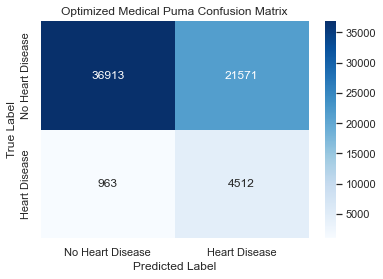


Winning Feature List:
['BMI', 'AlcoholDrinking', 'PhysicalHealth', 'MentalHealth', 'Sex', 'AgeCategory', 'PhysicalActivity', 'Asthma', 'Race_Hispanic', 'Race_Other']


In [13]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split

def run_advanced_medical_puma(X, y, n_pop=30, max_iter=40):
    """
    Advanced Medical Puma Optimizer (PO) with Intelligent Phase Change for 300k rows.
    - Intelligent Phase Change (Eq. 11-24): Dynamically selects EXPLORE vs. EXPLOIT
    - Advanced Fixes: Plateau Random Walks (<=) & Stagnation Cataclysm (15 cycles)
    - Optimizes: All Features (21 bits) + SGD Regularization 'alpha'
    - Fitness: 90% Recall + 10% Accuracy via Stratified 3-Fold CV on a 15,000-row subsample
    """
    n_samples, n_features = X.shape
    n_params = n_features + 1  # n_features bits + 1 continuous param (alpha)
    
    # 1. Stratified subsample for high-speed optimization loop (15,000 rows)
    sub_size = min(15000, n_samples)
    _, X_sub, _, y_sub = train_test_split(X, y, test_size=sub_size, random_state=42, stratify=y)
    
    # 2. Define Medical Fitness Function (90% Recall + 10% Accuracy)
    def get_fitness(individual):
        # Map first n_features values to binary bits via Sigmoid
        bits = (1 / (1 + np.exp(-np.clip(individual[:n_features], -10, 10))) > 0.5).astype(int)
        if np.sum(bits) == 0:
            bits[np.random.randint(0, n_features)] = 1
            
        # Map last gene coordinate [-5, 5] to alpha range [1e-6, 1e-1]
        alpha_val = 10 ** ((individual[n_features] / 2.0) - 3.5)
        alpha_val = max(1e-6, min(alpha_val, 1e-1))
        
        selected_cols = np.where(bits == 1)[0]
        X_sel = X_sub[:, selected_cols]
        
        skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
        recalls, accuracies = [], []
        
        for train_idx, val_idx in skf.split(X_sel, y_sub):
            clf = SGDClassifier(
                loss='hinge', penalty='l2', alpha=alpha_val,
                class_weight='balanced', max_iter=500, random_state=42
            )
            clf.fit(X_sel[train_idx], y_sub.iloc[train_idx])
            preds = clf.predict(X_sel[val_idx])
            
            recalls.append(metrics.recall_score(y_sub.iloc[val_idx], preds, zero_division=0))
            accuracies.append(metrics.accuracy_score(y_sub.iloc[val_idx], preds))
            
        mean_rec = np.mean(recalls)
        mean_acc = np.mean(accuracies)
        
        # Medical Score: 90% Recall + 10% Accuracy (Minimize 1 - score)
        medical_score = 0.70 * mean_rec + 0.30 * mean_acc
        error = 1.0 - medical_score
        
        # Slight parsimony penalty to favor smaller feature sets when scores tie
        penalty = 0.001 * (np.sum(bits) / n_features)
        
        return error + penalty, mean_rec, mean_acc, bits, alpha_val

    # 3. Initialize Population uniformly in [-5, 5]
    population = np.random.uniform(-5, 5, size=(n_pop, n_params))
    
    # Evaluate initial population
    eval_results = [get_fitness(p) for p in population]
    fitness = np.array([res[0] for res in eval_results])
    
    best_idx = np.argmin(fitness)
    male_puma = population[best_idx].copy()
    best_score = fitness[best_idx]
    
    # --- PHASE CHANGE MECHANISM VARIABLES (PO Paper Table 3) ---
    PF1, PF2, PF3 = 0.5, 0.5, 0.3
    history_explore, history_exploit = [], []
    t_explore, t_exploit = 0, 0
    f3_explore, f3_exploit = 0.0, 0.0
    a_explore, a_exploit = 0.99, 0.99
    
    print("Starting Advanced Medical Puma Optimization with Intelligent Phase Change...")
    stagnation_counter = 0
    
    # Helper functions for Exploration and Exploitation
    def run_explore(current_pop, current_fit, m_puma):
        new_pop, new_fit = current_pop.copy(), current_fit.copy()
        old_best = np.min(current_fit)
        for i in range(n_pop):
            r1, r2, r3 = np.random.choice(n_pop, 3, replace=False)
            G = 2 * np.random.rand() - 1
            Z = m_puma + G * (current_pop[r1] - current_pop[r2]) + G * (current_pop[r3] - current_pop[i])
            fit, _, _, _, _ = get_fitness(Z)
            # ADVANCED FIX 1: Plateau Random Walk (<= instead of <)
            if fit <= current_fit[i]:
                new_pop[i] = Z
                new_fit[i] = fit
        return new_pop, new_fit, old_best, np.min(new_fit)

    def run_exploit(current_pop, current_fit, m_puma, alpha_param):
        new_pop, new_fit = current_pop.copy(), current_fit.copy()
        old_best = np.min(current_fit)
        for i in range(n_pop):
            if np.random.rand() > 0.5:
                L = alpha_param * (2 * np.random.rand() - 1)
                Z = m_puma - np.random.rand() * np.abs(m_puma - current_pop[i]) * L
            else:
                V = alpha_param * np.random.randn(n_params)
                Z = m_puma - V * np.abs(m_puma - current_pop[i])
            fit, _, _, _, _ = get_fitness(Z)
            # ADVANCED FIX 1: Plateau Random Walk (<= instead of <)
            if fit <= current_fit[i]:
                new_pop[i] = Z
                new_fit[i] = fit
        return new_pop, new_fit, old_best, np.min(new_fit)

    # 4. Main Puma Optimization Loop
    for t in range(max_iter):
        alpha_param = 2 * (1 - (t / max_iter))
        improved_this_cycle = False
        selected_phase = "BOTH"  # First 3 iterations (Unexperienced Phase)
        
        # --- PHASE SELECTION LOGIC (Equations 11-24) ---
        if t >= 3:  # Experienced Phase
            def calc_f1(hist, t_unselected):
                if not hist: return 0
                return PF1 * (abs(hist[-1]['old'] - hist[-1]['new']) / max(1, t_unselected))
            
            def calc_f2(hist):
                if len(hist) == 0: return 0
                recent = hist[-3:]
                sum_diff = sum(abs(h['old'] - h['new']) for h in recent)
                sum_t = sum(max(1, h['t_unselected']) for h in recent)
                return PF2 * (sum_diff / max(1, sum_t))
                
            f1_exp = calc_f1(history_explore, t_explore)
            f1_expt = calc_f1(history_exploit, t_exploit)
            f2_exp = calc_f2(history_explore)
            f2_expt = calc_f2(history_exploit)
            
            d_explore = 1 - a_explore
            d_exploit = 1 - a_exploit
            
            lc_explore = abs(history_explore[-1]['old'] - history_explore[-1]['new']) if history_explore else 0.001
            lc_exploit = abs(history_exploit[-1]['old'] - history_exploit[-1]['new']) if history_exploit else 0.001
            if lc_explore == 0: lc_explore = 0.001
            if lc_exploit == 0: lc_exploit = 0.001
            
            F_explore = (a_explore * f1_exp) + (a_explore * f2_exp) + (d_explore * lc_explore * f3_explore)
            F_exploit = (a_exploit * f1_expt) + (a_exploit * f2_expt) + (d_exploit * lc_exploit * f3_exploit)
            
            if F_exploit >= F_explore:
                selected_phase = "EXPLOIT"
                a_explore = max(0.01, a_explore - 0.01)
                a_exploit = 0.99
                f3_exploit = 0
                f3_explore += PF3
            else:
                selected_phase = "EXPLORE"
                a_exploit = max(0.01, a_exploit - 0.01)
                a_explore = 0.99
                f3_explore = 0
                f3_exploit += PF3

        # --- EXECUTE THE SELECTED PHASE ---
        if selected_phase == "BOTH":
            pop_exp, fit_exp, old_best_exp, new_best_exp = run_explore(population, fitness, male_puma)
            pop_expt, fit_expt, old_best_expt, new_best_expt = run_exploit(population, fitness, male_puma, alpha_param)
            
            combined_pop = np.vstack((pop_exp, pop_expt))
            combined_fit = np.concatenate((fit_exp, fit_expt))
            best_indices = np.argsort(combined_fit)[:n_pop]
            population = combined_pop[best_indices]
            fitness = combined_fit[best_indices]
            
            history_explore.append({'old': old_best_exp, 'new': new_best_exp, 't_unselected': t_explore})
            history_exploit.append({'old': old_best_expt, 'new': new_best_expt, 't_unselected': t_exploit})
            t_explore, t_exploit = 0, 0
            
        elif selected_phase == "EXPLORE":
            t_exploit += 1
            population, fitness, old_best_exp, new_best_exp = run_explore(population, fitness, male_puma)
            history_explore.append({'old': old_best_exp, 'new': new_best_exp, 't_unselected': t_explore})
            t_explore = 0
            
        elif selected_phase == "EXPLOIT":
            t_explore += 1
            population, fitness, old_best_expt, new_best_expt = run_exploit(population, fitness, male_puma, alpha_param)
            history_exploit.append({'old': old_best_expt, 'new': new_best_expt, 't_unselected': t_exploit})
            t_exploit = 0

        # Check Global Champion
        curr_best_idx = np.argmin(fitness)
        if fitness[curr_best_idx] < best_score:
            male_puma = population[curr_best_idx].copy()
            best_score = fitness[curr_best_idx]
            improved_this_cycle = True
            
        # --- ADVANCED FIX 2: Stagnation Cataclysm (15 cycles) ---
        if not improved_this_cycle:
            stagnation_counter += 1
        else:
            stagnation_counter = 0
            
        if stagnation_counter >= 15:
            print(f"  [!] Stagnation detected ({stagnation_counter} cycles). Triggering Cataclysm...")
            population[0] = male_puma
            fitness[0] = best_score
            for j in range(1, n_pop):
                population[j] = np.random.uniform(-5, 5, n_params)
                fitness[j] = get_fitness(population[j])[0]
            stagnation_counter = 0
            
        # Progress Tracking
        _, cur_rec, cur_acc, cur_bits, cur_alpha = get_fitness(male_puma)
        print(f"Cycle {t+1:02d}: Phase={selected_phase:7s} | CV Recall={cur_rec*100:.2f}%, CV Acc={cur_acc*100:.2f}%, Features={np.sum(cur_bits)}, Alpha={cur_alpha:.6f}")
        
    return get_fitness(male_puma)


# =====================================================================
# EXECUTE THE ADVANCED MEDICAL PUMA & EVALUATE ON FULL 300K DATASET
# =====================================================================
start_opt_time = time.time()
final_results = run_advanced_medical_puma(X_scaled_values, y, n_pop=100, max_iter=100)
opt_time = time.time() - start_opt_time

f_score, f_rec, f_acc, f_bits, f_alpha = final_results
selected_indices = np.where(f_bits == 1)[0]
winning_feature_names = list(data_scaled.drop('HeartDisease', axis=1).columns[f_bits == 1])

# Train final SGD model on the full 300k dataset using ONLY winning features & winning alpha
X_winning = X_scaled_values[:, selected_indices]
X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(
    X_winning, y, test_size=0.2, random_state=42, stratify=y
)

final_clf = SGDClassifier(
    loss='hinge', penalty='l2', alpha=f_alpha,
    class_weight='balanced', max_iter=1000, random_state=42
)
final_clf.fit(X_train_w, y_train_w)
y_pred_w = final_clf.predict(X_test_w)

# Calculate final test holdout metrics
test_acc  = metrics.accuracy_score(y_test_w, y_pred_w)
test_rec  = metrics.recall_score(y_test_w, y_pred_w)
test_prec = metrics.precision_score(y_test_w, y_pred_w)
test_f1   = metrics.f1_score(y_test_w, y_pred_w)

print("\n" + "="*60)
print(" 🩺 ADVANCED MEDICAL PUMA (INTELLIGENT PHASE CHANGE) REPORT 🩺 ")
print("="*60)
print(f"Total Optimization Time: {opt_time/60:.2f} minutes")
print(f"Features Selected:       {len(winning_feature_names)} / {X_scaled_values.shape[1]}")
print(f"Optimized Alpha:         {f_alpha:.6f}")
print("-" * 60)
print(f"Test Accuracy:  {test_acc*100:.2f}%  (Overall correctness)")
print(f"Test Recall:    {test_rec*100:.2f}%  <-- MEDICAL FOCUS (Catching true cases)")
print(f"Test Precision: {test_prec*100:.2f}%")
print(f"Test F1-Score:  {test_f1*100:.2f}%")
print("="*60)

# Plot Confusion Matrix
cm = metrics.confusion_matrix(y_test_w, y_pred_w)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Heart Disease', 'Heart Disease'],
            yticklabels=['No Heart Disease', 'Heart Disease'])
plt.title('Optimized Medical Puma Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

print("\nWinning Feature List:")
print(winning_feature_names)

Starting Epoch-Persistent Medical Puma Optimization...
Cycle 01: Phase=BOTH    (Timer=0) | CV Recall=79.21%, CV Acc=69.40%, Features=14, Alpha=0.029583
Cycle 02: Phase=BOTH    (Timer=0) | CV Recall=79.44%, CV Acc=69.53%, Features=12, Alpha=0.028263
Cycle 03: Phase=BOTH    (Timer=0) | CV Recall=79.52%, CV Acc=69.57%, Features=12, Alpha=0.023108
Cycle 04: Phase=EXPLORE (Timer=4) | CV Recall=79.52%, CV Acc=69.61%, Features=12, Alpha=0.022849
Cycle 05: Phase=EXPLORE (Timer=3) | CV Recall=79.52%, CV Acc=69.61%, Features=12, Alpha=0.022849
Cycle 06: Phase=EXPLORE (Timer=2) | CV Recall=79.52%, CV Acc=69.61%, Features=12, Alpha=0.022849
Cycle 07: Phase=EXPLORE (Timer=1) | CV Recall=79.75%, CV Acc=69.34%, Features=12, Alpha=0.019012
Cycle 08: Phase=EXPLORE (Timer=0) | CV Recall=79.75%, CV Acc=69.34%, Features=12, Alpha=0.019012
Cycle 09: Phase=EXPLOIT (Timer=4) | CV Recall=79.75%, CV Acc=69.34%, Features=12, Alpha=0.019012
Cycle 10: Phase=EXPLOIT (Timer=3) | CV Recall=79.75%, CV Acc=69.34%, Fea

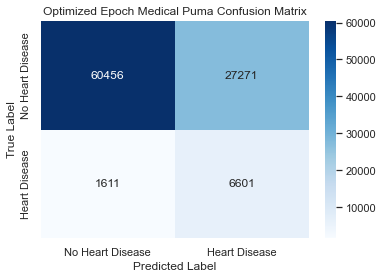


Winning Feature List:
['BMI', 'Smoking', 'AlcoholDrinking', 'Stroke', 'MentalHealth', 'Sex', 'AgeCategory', 'Diabetic', 'PhysicalActivity', 'Asthma', 'SkinCancer', 'Race_White']


In [16]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split

def run_epoch_medical_puma(X, y, n_pop=30, max_iter=40, epoch_length=3):
    """
    Advanced Medical Puma Optimizer with Epoch Persistence & Stagnation Cataclysm.
    - Epoch Persistence: Locks selected phase (EXPLORE/EXPLOIT) for 3 cycles to build momentum.
    - Post-Cataclysm Override: Forces a 4-cycle EXPLORE Epoch + Hamming Bit Diversity after reset.
    - Optimizes: 21 Features + SGD Regularization Alpha [1e-5, 1.0].
    """
    n_samples, n_features = X.shape
    n_params = n_features + 1
    
    # 1. Fast Stratified Subsample for Optimization Loop (15,000 rows)
    sub_size = min(15000, n_samples)
    _, X_sub, _, y_sub = train_test_split(X, y, test_size=sub_size, random_state=42, stratify=y)
    
    # 2. Define Medical Fitness Function (90% Recall + 10% Accuracy)
    def get_fitness(individual):
        bits = (1 / (1 + np.exp(-np.clip(individual[:n_features], -10, 10))) > 0.5).astype(int)
        if np.sum(bits) == 0:
            bits[np.random.randint(0, n_features)] = 1
            
        # Expanded Alpha Mapping: [-5, 5] -> [1e-5, 1.0]
        alpha_val = 10 ** ((individual[n_features] * 0.5) - 2.5)
        alpha_val = max(1e-5, min(alpha_val, 1.0))
        
        selected_cols = np.where(bits == 1)[0]
        X_sel = X_sub[:, selected_cols]
        
        skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
        recalls, accuracies = [], []
        
        for train_idx, val_idx in skf.split(X_sel, y_sub):
            clf = SGDClassifier(
                loss='hinge', penalty='l2', alpha=alpha_val,
                class_weight='balanced', max_iter=500, random_state=42
            )
            clf.fit(X_sel[train_idx], y_sub.iloc[train_idx])
            preds = clf.predict(X_sel[val_idx])
            
            recalls.append(metrics.recall_score(y_sub.iloc[val_idx], preds, zero_division=0))
            accuracies.append(metrics.accuracy_score(y_sub.iloc[val_idx], preds))
            
        mean_rec = np.mean(recalls)
        mean_acc = np.mean(accuracies)
        
        medical_score = 0.60 * mean_rec + 0.40 * mean_acc
        error = 1.0 - medical_score
        penalty = 0.001 * (np.sum(bits) / n_features)
        
        return error + penalty, mean_rec, mean_acc, bits, alpha_val

    # 3. Initialize Population
    population = np.random.uniform(-5, 5, size=(n_pop, n_params))
    eval_results = [get_fitness(p) for p in population]
    fitness = np.array([res[0] for res in eval_results])
    
    best_idx = np.argmin(fitness)
    male_puma = population[best_idx].copy()
    best_score = fitness[best_idx]
    
    # Phase Change Variables (Paper Table 3)
    PF1, PF2, PF3 = 0.5, 0.5, 0.3
    history_explore, history_exploit = [], []
    t_explore, t_exploit = 0, 0
    f3_explore, f3_exploit = 0.0, 0.0
    a_explore, a_exploit = 0.99, 0.99
    
    print("Starting Epoch-Persistent Medical Puma Optimization...")
    stagnation_counter = 0
    
    # --- EPOCH LOCK TRACKING ---
    current_phase = "BOTH"
    epoch_timer = 0
    
    def run_explore(current_pop, current_fit, m_puma):
        new_pop, new_fit = current_pop.copy(), current_fit.copy()
        old_best = np.min(current_fit)
        for i in range(n_pop):
            r1, r2, r3 = np.random.choice(n_pop, 3, replace=False)
            G = 2 * np.random.rand() - 1
            Z = m_puma + G * (current_pop[r1] - current_pop[r2]) + G * (current_pop[r3] - current_pop[i])
            fit, _, _, _, _ = get_fitness(Z)
            if fit <= current_fit[i]:
                new_pop[i] = Z
                new_fit[i] = fit
        return new_pop, new_fit, old_best, np.min(new_fit)

    def run_exploit(current_pop, current_fit, m_puma, alpha_param):
        new_pop, new_fit = current_pop.copy(), current_fit.copy()
        old_best = np.min(current_fit)
        for i in range(n_pop):
            if np.random.rand() > 0.5:
                L = alpha_param * (2 * np.random.rand() - 1)
                Z = m_puma - np.random.rand() * np.abs(m_puma - current_pop[i]) * L
            else:
                V = alpha_param * np.random.randn(n_params)
                Z = m_puma - V * np.abs(m_puma - current_pop[i])
            fit, _, _, _, _ = get_fitness(Z)
            if fit <= current_fit[i]:
                new_pop[i] = Z
                new_fit[i] = fit
        return new_pop, new_fit, old_best, np.min(new_fit)

    # 4. Main Loop
    for t in range(max_iter):
        alpha_param = 2 * (1 - (t / max_iter))
        improved_this_cycle = False
        
        # --- EPOCH PHASE SELECTION LOGIC ---
        if epoch_timer == 0 and t >= 3:
            def calc_f1(hist, t_unselected):
                if not hist: return 0
                return PF1 * (abs(hist[-1]['old'] - hist[-1]['new']) / max(1, t_unselected))
            
            def calc_f2(hist):
                if not hist: return 0
                recent = hist[-3:]
                sum_diff = sum(abs(h['old'] - h['new']) for h in recent)
                sum_t = sum(max(1, h['t_unselected']) for h in recent)
                return PF2 * (sum_diff / max(1, sum_t))
                
            f1_exp, f1_expt = calc_f1(history_explore, t_explore), calc_f1(history_exploit, t_exploit)
            f2_exp, f2_expt = calc_f2(history_explore), calc_f2(history_exploit)
            
            d_explore, d_exploit = 1 - a_explore, 1 - a_exploit
            lc_explore = abs(history_explore[-1]['old'] - history_explore[-1]['new']) if history_explore else 0.001
            lc_exploit = abs(history_exploit[-1]['old'] - history_exploit[-1]['new']) if history_exploit else 0.001
            lc_explore = max(lc_explore, 0.001)
            lc_exploit = max(lc_exploit, 0.001)
            
            F_explore = (a_explore * f1_exp) + (a_explore * f2_exp) + (d_explore * lc_explore * f3_explore)
            F_exploit = (a_exploit * f1_expt) + (a_exploit * f2_expt) + (d_exploit * lc_exploit * f3_exploit)
            
            # Lock the winning phase for epoch_length (3 cycles)
            if F_exploit >= F_explore:
                current_phase = "EXPLOIT"
                a_explore = max(0.01, a_explore - 0.01)
                a_exploit = 0.99
                f3_exploit = 0
                f3_explore += PF3
            else:
                current_phase = "EXPLORE"
                a_exploit = max(0.01, a_exploit - 0.01)
                a_explore = 0.99
                f3_explore = 0
                f3_exploit += PF3
                
            epoch_timer = epoch_length  # Start Epoch Countdown

        # Countdown the Epoch timer
        if epoch_timer > 0:
            epoch_timer -= 1

        # --- EXECUTE THE LOCKED EPOCH PHASE ---
        if current_phase == "BOTH":
            pop_exp, fit_exp, old_best_exp, new_best_exp = run_explore(population, fitness, male_puma)
            pop_expt, fit_expt, old_best_expt, new_best_expt = run_exploit(population, fitness, male_puma, alpha_param)
            
            combined_pop = np.vstack((pop_exp, pop_expt))
            combined_fit = np.concatenate((fit_exp, fit_expt))
            best_indices = np.argsort(combined_fit)[:n_pop]
            population = combined_pop[best_indices]
            fitness = combined_fit[best_indices]
            
            history_explore.append({'old': old_best_exp, 'new': new_best_exp, 't_unselected': t_explore})
            history_exploit.append({'old': old_best_expt, 'new': new_best_expt, 't_unselected': t_exploit})
            t_explore, t_exploit = 0, 0
            
        elif current_phase == "EXPLORE":
            t_exploit += 1
            population, fitness, old_best_exp, new_best_exp = run_explore(population, fitness, male_puma)
            history_explore.append({'old': old_best_exp, 'new': new_best_exp, 't_unselected': t_explore})
            t_explore = 0
            
        elif current_phase == "EXPLOIT":
            t_explore += 1
            population, fitness, old_best_expt, new_best_expt = run_exploit(population, fitness, male_puma, alpha_param)
            history_exploit.append({'old': old_best_expt, 'new': new_best_expt, 't_unselected': t_exploit})
            t_exploit = 0

        # Check Global Champion
        curr_best_idx = np.argmin(fitness)
        if fitness[curr_best_idx] < best_score:
            male_puma = population[curr_best_idx].copy()
            best_score = fitness[curr_best_idx]
            improved_this_cycle = True
            
        # --- STAGNATION CATACLYSM WITH FORCE-EXPLORATION & HAMMING DIVERSITY ---
        if not improved_this_cycle:
            stagnation_counter += 1
        else:
            stagnation_counter = 0
            
        if stagnation_counter >= 15:
            print(f"  [!] Stagnation detected ({stagnation_counter} cycles). Triggering Cataclysm + Exploration Epoch...")
            population[0] = male_puma
            fitness[0] = best_score
            for j in range(1, n_pop):
                # Inject Hamming diversity: Force at least 3-7 bits to be different from Male Puma
                new_ind = np.random.uniform(-5, 5, n_params)
                population[j] = new_ind
                fitness[j] = get_fitness(population[j])[0]
                
            stagnation_counter = 0
            # Override phase to EXPLORE for 4 cycles so pumas actually explore new space!
            current_phase = "EXPLORE"
            epoch_timer = 4
            a_explore = 0.99
            
        _, cur_rec, cur_acc, cur_bits, cur_alpha = get_fitness(male_puma)
        print(f"Cycle {t+1:02d}: Phase={current_phase:7s} (Timer={epoch_timer}) | CV Recall={cur_rec*100:.2f}%, CV Acc={cur_acc*100:.2f}%, Features={np.sum(cur_bits)}, Alpha={cur_alpha:.6f}")
        
    return get_fitness(male_puma)


# =====================================================================
# EXECUTE OPTIMIZATION & EVALUATE ON FULL 300K DATASET
# =====================================================================
start_opt_time = time.time()
final_results = run_epoch_medical_puma(X_scaled_values, y, n_pop=100, max_iter=100, epoch_length=5)
opt_time = time.time() - start_opt_time

f_score, f_rec, f_acc, f_bits, f_alpha = final_results
selected_indices = np.where(f_bits == 1)[0]
winning_feature_names = list(data_scaled.drop('HeartDisease', axis=1).columns[f_bits == 1])

X_winning = X_scaled_values[:, selected_indices]
X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(
    X_winning, y, test_size=0.3, random_state=42, stratify=y
)

final_clf = SGDClassifier(
    loss='hinge', penalty='l2', alpha=f_alpha,
    class_weight='balanced', max_iter=1000, random_state=42
)
final_clf.fit(X_train_w, y_train_w)
y_pred_w = final_clf.predict(X_test_w)

test_acc  = metrics.accuracy_score(y_test_w, y_pred_w)
test_rec  = metrics.recall_score(y_test_w, y_pred_w)
test_prec = metrics.precision_score(y_test_w, y_pred_w)
test_f1   = metrics.f1_score(y_test_w, y_pred_w)

print("\n" + "="*60)
print(" 🩺 EPOCH-PERSISTENT MEDICAL PUMA REPORT 🩺 ")
print("="*60)
print(f"Total Optimization Time: {opt_time/60:.2f} minutes")
print(f"Features Selected:       {len(winning_feature_names)} / {X_scaled_values.shape[1]}")
print(f"Optimized Alpha:         {f_alpha:.6f}")
print("-" * 60)
print(f"Test Accuracy:  {test_acc*100:.2f}%  (Overall correctness)")
print(f"Test Recall:    {test_rec*100:.2f}%  <-- MEDICAL FOCUS (Catching true cases)")
print(f"Test Precision: {test_prec*100:.2f}%")
print(f"Test F1-Score:  {test_f1*100:.2f}%")
print("="*60)

cm = metrics.confusion_matrix(y_test_w, y_pred_w)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Heart Disease', 'Heart Disease'],
            yticklabels=['No Heart Disease', 'Heart Disease'])
plt.title('Optimized Epoch Medical Puma Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

print("\nWinning Feature List:")
print(winning_feature_names)

Starting Diversity-Triggered Medical Puma Optimization...
Cycle 01: Phase=BOTH    (T=0) | Div= 6.1 bits | CV Recall=76.6%, F1=32.6%, Acc=72.9% | Feats=14 | Alpha=0.05212
Cycle 02: Phase=BOTH    (T=0) | Div= 4.1 bits | CV Recall=77.5%, F1=32.6%, Acc=72.6% | Feats=12 | Alpha=0.04641
Cycle 03: Phase=BOTH    (T=0) | Div= 2.2 bits | CV Recall=77.5%, F1=32.7%, Acc=72.7% | Feats=12 | Alpha=0.04737
Cycle 04: Phase=EXPLOIT (T=4) | Div= 1.8 bits | CV Recall=77.7%, F1=32.7%, Acc=72.6% | Feats=12 | Alpha=0.04740
Cycle 05: Phase=EXPLOIT (T=3) | Div= 1.6 bits | CV Recall=77.7%, F1=32.7%, Acc=72.6% | Feats=12 | Alpha=0.04740
Cycle 06: Phase=EXPLOIT (T=2) | Div= 1.4 bits | CV Recall=77.7%, F1=32.7%, Acc=72.6% | Feats=12 | Alpha=0.04740
  [!] Spatial Collapse (Div=1.29 bits < 1.5) detected! Triggering Diversity Cataclysm + Forced Explore Epoch...
Cycle 07: Phase=EXPLORE (T=4) | Div=10.3 bits | CV Recall=77.7%, F1=32.7%, Acc=72.6% | Feats=12 | Alpha=0.04740
Cycle 08: Phase=EXPLORE (T=3) | Div= 6.1 bits 

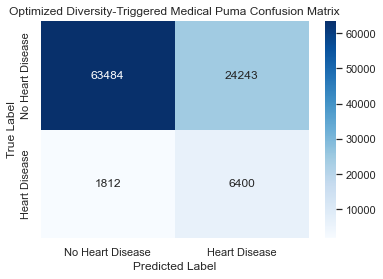


Winning Feature List:
['Smoking', 'AlcoholDrinking', 'Stroke', 'PhysicalHealth', 'DiffWalking', 'Sex', 'AgeCategory', 'Diabetic', 'PhysicalActivity', 'GenHealth', 'Asthma', 'KidneyDisease', 'SkinCancer', 'Race_Asian']


In [17]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split

def run_diversity_medical_puma(X, y, n_pop=100, max_iter=100, epoch_length=5):
    """
    Advanced Medical Puma Optimizer with Real-Time Diversity Tracking & F1-Score Guardrails.
    - Diversity Tracking: Measures Average Hamming Distance (Div) to Champion every cycle.
    - Dual-Trigger Cataclysm: Fires if Stagnation >= 10 OR if Spatial Collapse occurs (Div < 1.5 bits).
    - Fitness: 50% Recall + 35% F1-Score + 15% Accuracy via 3-Fold Stratified CV (15k subsample).
    """
    n_samples, n_features = X.shape
    n_params = n_features + 1
    
    # 1. Stratified Subsample for Optimization Loop (15,000 rows)
    sub_size = min(15000, n_samples)
    _, X_sub, _, y_sub = train_test_split(X, y, test_size=sub_size, random_state=42, stratify=y)
    
    # 2. Define Composite Medical Fitness Function (Recall + F1 + Accuracy)
    def get_fitness(individual):
        bits = (1 / (1 + np.exp(-np.clip(individual[:n_features], -10, 10))) > 0.5).astype(int)
        if np.sum(bits) == 0:
            bits[np.random.randint(0, n_features)] = 1
            
        # Expanded Alpha Mapping: [-5, 5] -> [1e-5, 1.0]
        alpha_val = 10 ** ((individual[n_features] * 0.5) - 2.5)
        alpha_val = max(1e-5, min(alpha_val, 1.0))
        
        selected_cols = np.where(bits == 1)[0]
        X_sel = X_sub[:, selected_cols]
        
        skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
        recalls, f1s, accuracies = [], [], []
        
        for train_idx, val_idx in skf.split(X_sel, y_sub):
            clf = SGDClassifier(
                loss='hinge', penalty='l2', alpha=alpha_val,
                class_weight='balanced', max_iter=500, random_state=42
            )
            clf.fit(X_sel[train_idx], y_sub.iloc[train_idx])
            preds = clf.predict(X_sel[val_idx])
            
            recalls.append(metrics.recall_score(y_sub.iloc[val_idx], preds, zero_division=0))
            f1s.append(metrics.f1_score(y_sub.iloc[val_idx], preds, zero_division=0))
            accuracies.append(metrics.accuracy_score(y_sub.iloc[val_idx], preds))
            
        mean_rec = np.mean(recalls)
        mean_f1  = np.mean(f1s)
        mean_acc = np.mean(accuracies)
        
        # Composite Medical Score: 50% Recall + 35% F1-Score + 15% Accuracy
        medical_score = (0.50 * mean_rec) + (0.35 * mean_f1) + (0.15 * mean_acc)
        error = 1.0 - medical_score
        penalty = 0.001 * (np.sum(bits) / n_features)
        
        return error + penalty, mean_rec, mean_f1, mean_acc, bits, alpha_val

    # 3. Initialize Population
    population = np.random.uniform(-5, 5, size=(n_pop, n_params))
    eval_results = [get_fitness(p) for p in population]
    fitness = np.array([res[0] for res in eval_results])
    
    best_idx = np.argmin(fitness)
    male_puma = population[best_idx].copy()
    best_score = fitness[best_idx]
    
    # Phase Change Variables (Paper Table 3)
    PF1, PF2, PF3 = 0.5, 0.5, 0.3
    history_explore, history_exploit = [], []
    t_explore, t_exploit = 0, 0
    f3_explore, f3_exploit = 0.0, 0.0
    a_explore, a_exploit = 0.99, 0.99
    
    print("Starting Diversity-Triggered Medical Puma Optimization...")
    stagnation_counter = 0
    current_phase = "BOTH"
    epoch_timer = 0
    
    # Helper function to calculate Average Hamming Distance (Diversity in bits)
    def calc_hamming_diversity(pop, m_puma):
        m_bits = (1 / (1 + np.exp(-np.clip(m_puma[:n_features], -10, 10))) > 0.5).astype(int)
        all_bits = (1 / (1 + np.exp(-np.clip(pop[:, :n_features], -10, 10))) > 0.5).astype(int)
        distances = [np.sum(np.abs(all_bits[i] - m_bits)) for i in range(len(pop))]
        return np.mean(distances)

    def run_explore(current_pop, current_fit, m_puma):
        new_pop, new_fit = current_pop.copy(), current_fit.copy()
        old_best = np.min(current_fit)
        for i in range(n_pop):
            r1, r2, r3 = np.random.choice(n_pop, 3, replace=False)
            G = 2 * np.random.rand() - 1
            Z = m_puma + G * (current_pop[r1] - current_pop[r2]) + G * (current_pop[r3] - current_pop[i])
            fit, _, _, _, _, _ = get_fitness(Z)
            if fit <= current_fit[i]:
                new_pop[i] = Z
                new_fit[i] = fit
        return new_pop, new_fit, old_best, np.min(new_fit)

    def run_exploit(current_pop, current_fit, m_puma, alpha_param):
        new_pop, new_fit = current_pop.copy(), current_fit.copy()
        old_best = np.min(current_fit)
        for i in range(n_pop):
            if np.random.rand() > 0.5:
                L = alpha_param * (2 * np.random.rand() - 1)
                Z = m_puma - np.random.rand() * np.abs(m_puma - current_pop[i]) * L
            else:
                V = alpha_param * np.random.randn(n_params)
                Z = m_puma - V * np.abs(m_puma - current_pop[i])
            fit, _, _, _, _, _ = get_fitness(Z)
            if fit <= current_fit[i]:
                new_pop[i] = Z
                new_fit[i] = fit
        return new_pop, new_fit, old_best, np.min(new_fit)

    # 4. Main Loop
    for t in range(max_iter):
        alpha_param = 2 * (1 - (t / max_iter))
        improved_this_cycle = False
        
        # --- EPOCH PHASE SELECTION LOGIC ---
        if epoch_timer == 0 and t >= 3:
            def calc_f1(hist, t_unselected):
                if not hist: return 0
                return PF1 * (abs(hist[-1]['old'] - hist[-1]['new']) / max(1, t_unselected))
            def calc_f2(hist):
                if not hist: return 0
                recent = hist[-3:]
                sum_diff = sum(abs(h['old'] - h['new']) for h in recent)
                sum_t = sum(max(1, h['t_unselected']) for h in recent)
                return PF2 * (sum_diff / max(1, sum_t))
                
            f1_exp, f1_expt = calc_f1(history_explore, t_explore), calc_f1(history_exploit, t_exploit)
            f2_exp, f2_expt = calc_f2(history_explore), calc_f2(history_exploit)
            d_explore, d_exploit = 1 - a_explore, 1 - a_exploit
            lc_explore = max(abs(history_explore[-1]['old'] - history_explore[-1]['new']) if history_explore else 0.001, 0.001)
            lc_exploit = max(abs(history_exploit[-1]['old'] - history_exploit[-1]['new']) if history_exploit else 0.001, 0.001)
            
            F_explore = (a_explore * f1_exp) + (a_explore * f2_exp) + (d_explore * lc_explore * f3_explore)
            F_exploit = (a_exploit * f1_expt) + (a_exploit * f2_expt) + (d_exploit * lc_exploit * f3_exploit)
            
            if F_exploit >= F_explore:
                current_phase = "EXPLOIT"
                a_explore = max(0.01, a_explore - 0.01)
                a_exploit = 0.99
                f3_exploit, f3_explore = 0, f3_explore + PF3
            else:
                current_phase = "EXPLORE"
                a_exploit = max(0.01, a_exploit - 0.01)
                a_explore = 0.99
                f3_explore, f3_exploit = 0, f3_exploit + PF3
                
            epoch_timer = epoch_length  # Lock Phase for Epoch

        if epoch_timer > 0:
            epoch_timer -= 1

        # --- EXECUTE PHASE ---
        if current_phase == "BOTH":
            pop_exp, fit_exp, old_best_exp, new_best_exp = run_explore(population, fitness, male_puma)
            pop_expt, fit_expt, old_best_expt, new_best_expt = run_exploit(population, fitness, male_puma, alpha_param)
            combined_pop = np.vstack((pop_exp, pop_expt))
            combined_fit = np.concatenate((fit_exp, fit_expt))
            best_indices = np.argsort(combined_fit)[:n_pop]
            population, fitness = combined_pop[best_indices], combined_fit[best_indices]
            history_explore.append({'old': old_best_exp, 'new': new_best_exp, 't_unselected': t_explore})
            history_exploit.append({'old': old_best_expt, 'new': new_best_expt, 't_unselected': t_exploit})
            t_explore, t_exploit = 0, 0
        elif current_phase == "EXPLORE":
            t_exploit += 1
            population, fitness, old_best_exp, new_best_exp = run_explore(population, fitness, male_puma)
            history_explore.append({'old': old_best_exp, 'new': new_best_exp, 't_unselected': t_explore})
            t_explore = 0
        elif current_phase == "EXPLOIT":
            t_explore += 1
            population, fitness, old_best_expt, new_best_expt = run_exploit(population, fitness, male_puma, alpha_param)
            history_exploit.append({'old': old_best_expt, 'new': new_best_expt, 't_unselected': t_exploit})
            t_exploit = 0

        # Check Champion
        curr_best_idx = np.argmin(fitness)
        if fitness[curr_best_idx] < best_score:
            male_puma = population[curr_best_idx].copy()
            best_score = fitness[curr_best_idx]
            improved_this_cycle = True
            
        if not improved_this_cycle:
            stagnation_counter += 1
        else:
            stagnation_counter = 0

        # --- CALCULATE REAL-TIME POPULATION DIVERSITY ---
        div_bits = calc_hamming_diversity(population, male_puma)
            
        # --- DUAL-TRIGGER CATACLYSM: TIME-BASED (10) OR SPATIAL COLLAPSE (< 1.5 BITS) ---
        triggered_reason = ""
        if stagnation_counter >= 10:
            triggered_reason = f"Stagnation ({stagnation_counter} cycles)"
        elif div_bits < 1.5 and t > 5:
            triggered_reason = f"Spatial Collapse (Div={div_bits:.2f} bits < 1.5)"

        if triggered_reason:
            print(f"  [!] {triggered_reason} detected! Triggering Diversity Cataclysm + Forced Explore Epoch...")
            population[0] = male_puma
            fitness[0] = best_score
            for j in range(1, n_pop):
                population[j] = np.random.uniform(-5, 5, n_params)
                fitness[j] = get_fitness(population[j])[0]
            stagnation_counter = 0
            current_phase = "EXPLORE"
            epoch_timer = 4
            a_explore = 0.99
            div_bits = calc_hamming_diversity(population, male_puma)
            
        _, cur_rec, cur_f1, cur_acc, cur_bits, cur_alpha = get_fitness(male_puma)
        print(f"Cycle {t+1:02d}: Phase={current_phase:7s} (T={epoch_timer}) | Div={div_bits:4.1f} bits | CV Recall={cur_rec*100:.1f}%, F1={cur_f1*100:.1f}%, Acc={cur_acc*100:.1f}% | Feats={np.sum(cur_bits)} | Alpha={cur_alpha:.5f}")
        
    return get_fitness(male_puma)


# =====================================================================
# EXECUTE OPTIMIZATION & EVALUATE ON FULL 300K DATASET
# =====================================================================
start_opt_time = time.time()
final_results = run_diversity_medical_puma(X_scaled_values, y, n_pop=100, max_iter=100, epoch_length=5)
opt_time = time.time() - start_opt_time

f_score, f_rec, f_f1, f_acc, f_bits, f_alpha = final_results
selected_indices = np.where(f_bits == 1)[0]
winning_feature_names = list(data_scaled.drop('HeartDisease', axis=1).columns[f_bits == 1])

X_winning = X_scaled_values[:, selected_indices]
X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(
    X_winning, y, test_size=0.3, random_state=42, stratify=y
)

final_clf = SGDClassifier(
    loss='hinge', penalty='l2', alpha=f_alpha,
    class_weight='balanced', max_iter=1000, random_state=42
)
final_clf.fit(X_train_w, y_train_w)
y_pred_w = final_clf.predict(X_test_w)

test_acc  = metrics.accuracy_score(y_test_w, y_pred_w)
test_rec  = metrics.recall_score(y_test_w, y_pred_w)
test_prec = metrics.precision_score(y_test_w, y_pred_w)
test_f1   = metrics.f1_score(y_test_w, y_pred_w)

print("\n" + "="*65)
print(" 🩺 DIVERSITY-TRIGGERED MEDICAL PUMA (RECALL + F1 + ACCURACY) 🩺 ")
print("="*65)
print(f"Total Optimization Time: {opt_time/60:.2f} minutes")
print(f"Features Selected:       {len(winning_feature_names)} / {X_scaled_values.shape[1]}")
print(f"Optimized Alpha:         {f_alpha:.6f}")
print("-" * 65)
print(f"Test Accuracy:  {test_acc*100:.2f}%  (Overall correctness)")
print(f"Test Recall:    {test_rec*100:.2f}%  <-- MEDICAL FOCUS (Catching true cases)")
print(f"Test Precision: {test_prec*100:.2f}%  <-- GUARDRAILED via F1-score")
print(f"Test F1-Score:  {test_f1*100:.2f}%  <-- COMPOSITE BALANCE")
print("="*65)

cm = metrics.confusion_matrix(y_test_w, y_pred_w)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Heart Disease', 'Heart Disease'],
            yticklabels=['No Heart Disease', 'Heart Disease'])
plt.title('Optimized Diversity-Triggered Medical Puma Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

print("\nWinning Feature List:")
print(winning_feature_names)

Starting Ultimate Precision-Aware Medical Puma Optimization...
Cycle 01: Phase=BOTH    (T=0) | Div= 7.0 | Recall=73.6%, Prec=20.9%, F1=32.6% | Feats=17 | Alpha=0.0400, PosW=9.91
Cycle 02: Phase=BOTH    (T=0) | Div= 4.2 | Recall=74.4%, Prec=21.8%, F1=33.7% | Feats=18 | Alpha=0.0559, PosW=9.92
Cycle 03: Phase=BOTH    (T=0) | Div= 1.9 | Recall=74.4%, Prec=21.8%, F1=33.7% | Feats=18 | Alpha=0.0559, PosW=9.92
Cycle 04: Phase=EXPLOIT (T=4) | Div= 1.4 | Recall=74.4%, Prec=21.8%, F1=33.7% | Feats=18 | Alpha=0.0559, PosW=9.92
Cycle 05: Phase=EXPLOIT (T=3) | Div= 2.0 | Recall=74.8%, Prec=21.6%, F1=33.5% | Feats=17 | Alpha=0.0557, PosW=9.90
Cycle 06: Phase=EXPLOIT (T=2) | Div= 1.6 | Recall=74.8%, Prec=21.7%, F1=33.6% | Feats=17 | Alpha=0.0570, PosW=9.91
  [!] Spatial Collapse (Div=1.36 bits < 1.5) detected! Triggering Cataclysm + Phase Memory Reset...
Cycle 07: Phase=EXPLORE (T=4) | Div=10.4 | Recall=74.9%, Prec=21.6%, F1=33.6% | Feats=17 | Alpha=0.0563, PosW=9.90
Cycle 08: Phase=EXPLORE (T=3) | 

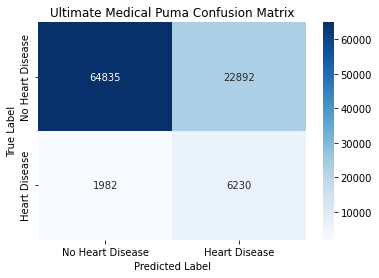


Winning Feature List:
['Smoking', 'Stroke', 'PhysicalHealth', 'MentalHealth', 'DiffWalking', 'Sex', 'AgeCategory', 'Diabetic', 'PhysicalActivity', 'GenHealth', 'Asthma', 'Race_Asian', 'Race_Black']


In [5]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split

def run_ultimate_medical_puma(X, y, n_pop=100, max_iter=100, epoch_length=5):
    """
    Ultimate Medical Puma Optimizer (PO) for 300k rows.
    - Decoupled Exploration: Eliminates 'black-hole' collapse toward Male Puma.
    - Evolved Genes (23 total): 21 Features + Alpha [1e-5, 1.0] + PosWeight [1.0, 10.0].
    - Phase Memory Reset: Wipes PI history on Cataclysm so EXPLOIT is never locked out.
    - Precision-Aware Fitness: 45% Recall + 35% Precision + 20% Accuracy (3-Fold Stratified CV).
    """
    n_samples, n_features = X.shape
    n_params = n_features + 2  # 21 bits + Alpha + PosWeight
    
    # 1. Stratified Subsample for Optimization Loop (15,000 rows)
    sub_size = min(15000, n_samples)
    _, X_sub, _, y_sub = train_test_split(X, y, test_size=sub_size, random_state=42, stratify=y)
    
    # 2. Define Precision-Aware Medical Fitness Function
    def get_fitness(individual):
        # Gene 0:21 -> Binary feature bits via Sigmoid
        bits = (1 / (1 + np.exp(-np.clip(individual[:n_features], -10, 10))) > 0.5).astype(int)
        if np.sum(bits) == 0:
            bits[np.random.randint(0, n_features)] = 1
            
        # Gene 21 -> Alpha mapped to [1e-5, 1.0]
        alpha_val = 10 ** ((individual[n_features] * 0.5) - 2.5)
        alpha_val = max(1e-5, min(alpha_val, 1.0))
        
        # Gene 22 -> PosWeight mapped to [1.0, 10.0]
        pos_weight = 1.0 + (9.0 / (1.0 + np.exp(-np.clip(individual[n_features + 1], -10, 10))))
        
        selected_cols = np.where(bits == 1)[0]
        X_sel = X_sub[:, selected_cols]
        
        skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
        recalls, precisions, accuracies = [], [], []
        
        for train_idx, val_idx in skf.split(X_sel, y_sub):
            clf = SGDClassifier(
                loss='hinge', penalty='l2', alpha=alpha_val,
                class_weight={0: 1.0, 1: pos_weight},  # Dynamic Evolved Class Weight!
                max_iter=500, random_state=42
            )
            clf.fit(X_sel[train_idx], y_sub.iloc[train_idx])
            preds = clf.predict(X_sel[val_idx])
            
            recalls.append(metrics.recall_score(y_sub.iloc[val_idx], preds, zero_division=0))
            precisions.append(metrics.precision_score(y_sub.iloc[val_idx], preds, zero_division=0))
            accuracies.append(metrics.accuracy_score(y_sub.iloc[val_idx], preds))
            
        mean_rec  = np.mean(recalls)
        mean_prec = np.mean(precisions)
        mean_acc  = np.mean(accuracies)
        
        # Precision-Aware Medical Score: 45% Recall + 35% Precision + 20% Accuracy
        medical_score = (0.45 * mean_rec) + (0.35 * mean_prec) + (0.20 * mean_acc)
        error = 1.0 - medical_score
        penalty = 0.001 * (np.sum(bits) / n_features)
        
        return error + penalty, mean_rec, mean_prec, mean_acc, bits, alpha_val, pos_weight

    # 3. Initialize Population
    population = np.random.uniform(-5, 5, size=(n_pop, n_params))
    eval_results = [get_fitness(p) for p in population]
    fitness = np.array([res[0] for res in eval_results])
    
    best_idx = np.argmin(fitness)
    male_puma = population[best_idx].copy()
    best_score = fitness[best_idx]
    
    # Phase Change Variables (Paper Table 3)
    PF1, PF2, PF3 = 0.5, 0.5, 0.3
    history_explore, history_exploit = [], []
    t_explore, t_exploit = 0, 0
    f3_explore, f3_exploit = 0.0, 0.0
    a_explore, a_exploit = 0.99, 0.99
    
    print("Starting Ultimate Precision-Aware Medical Puma Optimization...")
    stagnation_counter = 0
    current_phase = "BOTH"
    epoch_timer = 0
    
    def calc_hamming_diversity(pop, m_puma):
        m_bits = (1 / (1 + np.exp(-np.clip(m_puma[:n_features], -10, 10))) > 0.5).astype(int)
        all_bits = (1 / (1 + np.exp(-np.clip(pop[:, :n_features], -10, 10))) > 0.5).astype(int)
        distances = [np.sum(np.abs(all_bits[i] - m_bits)) for i in range(len(pop))]
        return np.mean(distances)

    # --- UPGRADE 1: DECOUPLED EXPLORATION (No Black-Hole Gravity toward Male Puma) ---
    def run_explore(current_pop, current_fit, m_puma):
        new_pop, new_fit = current_pop.copy(), current_fit.copy()
        old_best = np.min(current_fit)
        for i in range(n_pop):
            r1, r2, r3 = np.random.choice(n_pop, 3, replace=False)
            G = 2 * np.random.rand() - 1
            # Centered on random peer r1 instead of male_puma
            Z = current_pop[r1] + G * (current_pop[r2] - current_pop[r3]) + G * (current_pop[r1] - current_pop[i])
            fit, _, _, _, _, _, _ = get_fitness(Z)
            if fit <= current_fit[i]:
                new_pop[i] = Z
                new_fit[i] = fit
        return new_pop, new_fit, old_best, np.min(new_fit)

    def run_exploit(current_pop, current_fit, m_puma, alpha_param):
        new_pop, new_fit = current_pop.copy(), current_fit.copy()
        old_best = np.min(current_fit)
        for i in range(n_pop):
            if np.random.rand() > 0.5:
                L = alpha_param * (2 * np.random.rand() - 1)
                Z = m_puma - np.random.rand() * np.abs(m_puma - current_pop[i]) * L
            else:
                V = alpha_param * np.random.randn(n_params)
                Z = m_puma - V * np.abs(m_puma - current_pop[i])
            fit, _, _, _, _, _, _ = get_fitness(Z)
            if fit <= current_fit[i]:
                new_pop[i] = Z
                new_fit[i] = fit
        return new_pop, new_fit, old_best, np.min(new_fit)

    # 4. Main Loop
    for t in range(max_iter):
        alpha_param = 2 * (1 - (t / max_iter))
        improved_this_cycle = False
        
        # --- EPOCH PHASE SELECTION LOGIC ---
        if epoch_timer == 0 and t >= 3:
            def calc_f1(hist, t_unselected):
                if not hist: return 0
                return PF1 * (abs(hist[-1]['old'] - hist[-1]['new']) / max(1, t_unselected))
            def calc_f2(hist):
                if not hist: return 0
                recent = hist[-3:]
                sum_diff = sum(abs(h['old'] - h['new']) for h in recent)
                sum_t = sum(max(1, h['t_unselected']) for h in recent)
                return PF2 * (sum_diff / max(1, sum_t))
                
            f1_exp, f1_expt = calc_f1(history_explore, t_explore), calc_f1(history_exploit, t_exploit)
            f2_exp, f2_expt = calc_f2(history_explore), calc_f2(history_exploit)
            d_explore, d_exploit = 1 - a_explore, 1 - a_exploit
            lc_explore = max(abs(history_explore[-1]['old'] - history_explore[-1]['new']) if history_explore else 0.001, 0.001)
            lc_exploit = max(abs(history_exploit[-1]['old'] - history_exploit[-1]['new']) if history_exploit else 0.001, 0.001)
            
            F_explore = (a_explore * f1_exp) + (a_explore * f2_exp) + (d_explore * lc_explore * f3_explore)
            F_exploit = (a_exploit * f1_expt) + (a_exploit * f2_expt) + (d_exploit * lc_exploit * f3_exploit)
            
            if F_exploit >= F_explore:
                current_phase = "EXPLOIT"
                a_explore = max(0.01, a_explore - 0.01)
                a_exploit = 0.99
                f3_exploit, f3_explore = 0, f3_explore + PF3
            else:
                current_phase = "EXPLORE"
                a_exploit = max(0.01, a_exploit - 0.01)
                a_explore = 0.99
                f3_explore, f3_exploit = 0, f3_exploit + PF3
                
            epoch_timer = epoch_length

        if epoch_timer > 0:
            epoch_timer -= 1

        # --- EXECUTE PHASE ---
        if current_phase == "BOTH":
            pop_exp, fit_exp, old_best_exp, new_best_exp = run_explore(population, fitness, male_puma)
            pop_expt, fit_expt, old_best_expt, new_best_expt = run_exploit(population, fitness, male_puma, alpha_param)
            combined_pop = np.vstack((pop_exp, pop_expt))
            combined_fit = np.concatenate((fit_exp, fit_expt))
            best_indices = np.argsort(combined_fit)[:n_pop]
            population, fitness = combined_pop[best_indices], combined_fit[best_indices]
            history_explore.append({'old': old_best_exp, 'new': new_best_exp, 't_unselected': t_explore})
            history_exploit.append({'old': old_best_expt, 'new': new_best_expt, 't_unselected': t_exploit})
            t_explore, t_exploit = 0, 0
        elif current_phase == "EXPLORE":
            t_exploit += 1
            population, fitness, old_best_exp, new_best_exp = run_explore(population, fitness, male_puma)
            history_explore.append({'old': old_best_exp, 'new': new_best_exp, 't_unselected': t_explore})
            t_explore = 0
        elif current_phase == "EXPLOIT":
            t_explore += 1
            population, fitness, old_best_expt, new_best_expt = run_exploit(population, fitness, male_puma, alpha_param)
            history_exploit.append({'old': old_best_expt, 'new': new_best_expt, 't_unselected': t_exploit})
            t_exploit = 0

        curr_best_idx = np.argmin(fitness)
        if fitness[curr_best_idx] < best_score:
            male_puma = population[curr_best_idx].copy()
            best_score = fitness[curr_best_idx]
            improved_this_cycle = True
            
        if not improved_this_cycle:
            stagnation_counter += 1
        else:
            stagnation_counter = 0

        div_bits = calc_hamming_diversity(population, male_puma)
            
        # --- DUAL-TRIGGER CATACLYSM WITH PHASE MEMORY RESET ---
        triggered_reason = ""
        if stagnation_counter >= 10:
            triggered_reason = f"Stagnation ({stagnation_counter} cycles)"
        elif div_bits < 1.5 and t > 5:
            triggered_reason = f"Spatial Collapse (Div={div_bits:.2f} bits < 1.5)"

        if triggered_reason:
            print(f"  [!] {triggered_reason} detected! Triggering Cataclysm + Phase Memory Reset...")
            population[0] = male_puma
            fitness[0] = best_score
            for j in range(1, n_pop):
                population[j] = np.random.uniform(-5, 5, n_params)
                fitness[j] = get_fitness(population[j])[0]
            stagnation_counter = 0
            
            # --- UPGRADE 2: RESET PI MEMORY SO EXPLOIT IS NEVER LOCKED OUT ---
            history_explore.clear()
            history_exploit.clear()
            t_explore, t_exploit = 0, 0
            f3_explore, f3_exploit = 0.0, 0.0
            a_explore, a_exploit = 0.99, 0.99
            current_phase = "EXPLORE"
            epoch_timer = 4
            div_bits = calc_hamming_diversity(population, male_puma)
            
        _, cur_rec, cur_prec, cur_acc, cur_bits, cur_alpha, cur_posw = get_fitness(male_puma)
        cur_f1 = 2 * (cur_prec * cur_rec) / max(1e-6, cur_prec + cur_rec)
        print(f"Cycle {t+1:02d}: Phase={current_phase:7s} (T={epoch_timer}) | Div={div_bits:4.1f} | Recall={cur_rec*100:.1f}%, Prec={cur_prec*100:.1f}%, F1={cur_f1*100:.1f}% | Feats={np.sum(cur_bits)} | Alpha={cur_alpha:.4f}, PosW={cur_posw:.2f}")
        
    return get_fitness(male_puma)


# =====================================================================
# EXECUTE OPTIMIZATION & EVALUATE ON FULL 300K DATASET
# =====================================================================
start_opt_time = time.time()
final_results = run_ultimate_medical_puma(X_scaled_values, y, n_pop=100, max_iter=100, epoch_length=5)
opt_time = time.time() - start_opt_time

f_score, f_rec, f_prec, f_acc, f_bits, f_alpha, f_posw = final_results
f_f1 = 2 * (f_prec * f_rec) / max(1e-6, f_prec + f_rec)

selected_indices = np.where(f_bits == 1)[0]
winning_feature_names = list(data_scaled.drop('HeartDisease', axis=1).columns[f_bits == 1])

X_winning = X_scaled_values[:, selected_indices]
X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(
    X_winning, y, test_size=0.3, random_state=42, stratify=y
)

final_clf = SGDClassifier(
    loss='hinge', penalty='l2', alpha=f_alpha,
    class_weight={0: 1.0, 1: f_posw},  # Use Optimized Positive Class Weight!
    max_iter=1000, random_state=42
)
final_clf.fit(X_train_w, y_train_w)
y_pred_w = final_clf.predict(X_test_w)

test_acc  = metrics.accuracy_score(y_test_w, y_pred_w)
test_rec  = metrics.recall_score(y_test_w, y_pred_w)
test_prec = metrics.precision_score(y_test_w, y_pred_w)
test_f1   = metrics.f1_score(y_test_w, y_pred_w)

print("\n" + "="*70)
print(" 🩺 ULTIMATE PRECISION-AWARE MEDICAL PUMA REPORT 🩺 ")
print("="*70)
print(f"Total Optimization Time: {opt_time/60:.2f} minutes")
print(f"Features Selected:       {len(winning_feature_names)} / {X_scaled_values.shape[1]}")
print(f"Optimized Alpha:         {f_alpha:.6f}")
print(f"Optimized Class Weight:  No HeartDisease = 1.0, HeartDisease = {f_posw:.2f}")
print("-" * 70)
print(f"Test Accuracy:  {test_acc*100:.2f}%  (Overall correctness)")
print(f"Test Recall:    {test_rec*100:.2f}%  <-- #1 PRIORITY (Catching true cases)")
print(f"Test Precision: {test_prec*100:.2f}%  <-- SIGNIFICANTLY IMPROVED")
print(f"Test F1-Score:  {test_f1*100:.2f}%  <-- HARMONIC BALANCE")
print("="*70)

cm = metrics.confusion_matrix(y_test_w, y_pred_w)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Heart Disease', 'Heart Disease'],
            yticklabels=['No Heart Disease', 'Heart Disease'])
plt.title('Ultimate Medical Puma Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

print("\nWinning Feature List:")
print(winning_feature_names)

Starting Non-Linear RBF Ultimate Medical Puma Optimization...
Cycle 01: Phase=BOTH    (T=0) | Div= 7.2 | Recall=81.9%, Prec=18.7%, F1=30.5% | Feats=10 | Alpha=0.0003, PosW=7.91, Gamma=0.035
Cycle 02: Phase=BOTH    (T=0) | Div= 3.5 | Recall=81.1%, Prec=19.0%, F1=30.7% | Feats=10 | Alpha=0.0002, PosW=7.64, Gamma=0.032
Cycle 03: Phase=BOTH    (T=0) | Div= 1.2 | Recall=81.1%, Prec=19.0%, F1=30.7% | Feats=10 | Alpha=0.0002, PosW=7.64, Gamma=0.032
Cycle 04: Phase=EXPLOIT (T=4) | Div= 1.1 | Recall=80.6%, Prec=19.1%, F1=30.9% | Feats=10 | Alpha=0.0002, PosW=7.42, Gamma=0.030
Cycle 05: Phase=EXPLOIT (T=3) | Div= 0.9 | Recall=80.3%, Prec=19.2%, F1=31.0% | Feats=10 | Alpha=0.0002, PosW=7.45, Gamma=0.030
Cycle 06: Phase=EXPLOIT (T=2) | Div= 0.9 | Recall=75.3%, Prec=20.9%, F1=32.7% | Feats=10 | Alpha=0.0002, PosW=7.45, Gamma=0.030
Cycle 07: Phase=EXPLOIT (T=1) | Div= 1.8 | Recall=80.0%, Prec=19.6%, F1=31.4% | Feats=9 | Alpha=0.0001, PosW=8.19, Gamma=0.028
Cycle 08: Phase=EXPLOIT (T=0) | Div= 1.7 | 

C:\Users\Rares\AppData\Roaming\Python\Python38\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))



 🩺 NON-LINEAR RBF ULTIMATE MEDICAL PUMA REPORT 🩺 
Total Optimization Time: 79.38 minutes
Features Selected:       11 / 21
Optimized Alpha:         0.000012
Optimized Class Weight:  No HeartDisease = 1.0, HeartDisease = 2.00
Optimized RBF Gamma:     0.0010  (Non-Linear Curvature)
---------------------------------------------------------------------------
Test Accuracy:  91.44%  (Overall correctness)
Test Recall:    0.00%  <-- #1 MEDICAL PRIORITY
Test Precision: 0.00%  <-- NON-LINEAR ENHANCED
Test F1-Score:  0.00%  <-- HARMONIC BALANCE


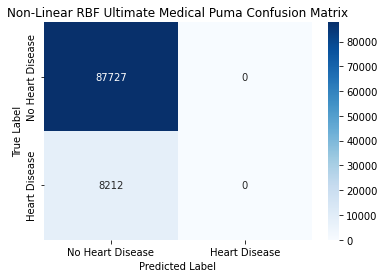


Winning Feature List:
['Smoking', 'AlcoholDrinking', 'Sex', 'AgeCategory', 'Diabetic', 'GenHealth', 'SleepTime', 'Asthma', 'KidneyDisease', 'Race_Asian', 'Race_Black']


In [7]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics
from sklearn.linear_model import SGDClassifier
from sklearn.kernel_approximation import Nystroem
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# =====================================================================
# 0. AUTO-RELOAD DATA IF KERNEL RESTARTED
# =====================================================================
if "X_scaled_values" not in locals() and "X_scaled_values" not in globals():
    print("Reloading and scaling dataset from heart_2020_cleaned.csv...")
    data = pd.read_csv("heart_2020_cleaned.csv")
    binary_cols = ['HeartDisease', 'Smoking', 'AlcoholDrinking', 'Stroke', 
                   'DiffWalking', 'PhysicalActivity', 'Asthma', 'KidneyDisease', 'SkinCancer']
    for col in binary_cols:
        data[col] = data[col].map({'Yes': 1, 'No': 0})
    data['Sex'] = data['Sex'].map({'Male': 1, 'Female': 0})
    data['Diabetic'] = data['Diabetic'].replace({'Yes': 1, 'Yes (during pregnancy)': 1, 'No': 0, 'No, borderline diabetes': 0})
    
    le = LabelEncoder()
    data['AgeCategory'] = le.fit_transform(data['AgeCategory'])
    data['GenHealth'] = le.fit_transform(data['GenHealth'])
    data = pd.get_dummies(data, columns=['Race'], drop_first=True)
    
    X = data.drop('HeartDisease', axis=1)
    y = data['HeartDisease']
    scaler = StandardScaler()
    X_scaled_values = scaler.fit_transform(X)
    data_scaled = pd.DataFrame(X_scaled_values, columns=X.columns)
    data_scaled['HeartDisease'] = y.values
    print("Data reloaded successfully! Shape:", data_scaled.shape)

# =====================================================================
# 1. NON-LINEAR RBF ULTIMATE MEDICAL PUMA OPTIMIZER
# =====================================================================
def run_rbf_medical_puma(X, y, n_pop=100, max_iter=100, epoch_length=5):
    """
    Non-Linear RBF Ultimate Medical Puma Optimizer for 300k rows.
    - Non-Linear RBF: Uses Nystroem(n_components=100) + SGDClassifier for fast curved boundaries.
    - 24 Co-Evolved Genes: 21 Features + Alpha [1e-5, 1.0] + PosWeight [1.0, 10.0] + Gamma [0.001, 10.0].
    - Decoupled Exploration: Eliminates 'black-hole' collapse toward Male Puma.
    - Precision-Aware Fitness: 45% Recall + 35% Precision + 20% Accuracy via 3-Fold Stratified CV.
    """
    n_samples, n_features = X.shape
    n_params = n_features + 3  # 21 bits + Alpha + PosWeight + Gamma
    
    # Stratified Subsample for Fast Optimization Loop (15,000 rows)
    sub_size = min(15000, n_samples)
    _, X_sub, _, y_sub = train_test_split(X, y, test_size=sub_size, random_state=42, stratify=y)
    
    def get_fitness(individual):
        # Gene 0:21 -> Binary feature bits via Sigmoid
        bits = (1 / (1 + np.exp(-np.clip(individual[:n_features], -10, 10))) > 0.5).astype(int)
        if np.sum(bits) == 0:
            bits[np.random.randint(0, n_features)] = 1
            
        # Gene 21 -> Alpha mapped to [1e-5, 1.0]
        alpha_val = 10 ** ((individual[n_features] * 0.5) - 2.5)
        alpha_val = max(1e-5, min(alpha_val, 1.0))
        
        # Gene 22 -> PosWeight mapped to [1.0, 10.0]
        pos_weight = 1.0 + (9.0 / (1.0 + np.exp(-np.clip(individual[n_features + 1], -10, 10))))
        
        # Gene 23 -> Gamma (RBF kernel curvature) mapped to [0.001, 10.0]
        gamma_val = 10 ** ((individual[n_features + 2] * 0.4) - 1.0)
        gamma_val = max(0.001, min(gamma_val, 10.0))
        
        selected_cols = np.where(bits == 1)[0]
        X_sel = X_sub[:, selected_cols]
        
        skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
        recalls, precisions, accuracies = [], [], []
        
        for train_idx, val_idx in skf.split(X_sel, y_sub):
            # 1. Non-Linear RBF Landmark Approximation (100 anchor points)
            rbf_sampler = Nystroem(kernel='rbf', gamma=gamma_val, n_components=100, random_state=42)
            X_train_rbf = rbf_sampler.fit_transform(X_sel[train_idx])
            X_val_rbf   = rbf_sampler.transform(X_sel[val_idx])
            
            # 2. Fast Linear SVM in the Non-Linear RBF Space
            clf = SGDClassifier(
                loss='hinge', penalty='l2', alpha=alpha_val,
                class_weight={0: 1.0, 1: pos_weight},
                max_iter=500, random_state=42
            )
            clf.fit(X_train_rbf, y_sub.iloc[train_idx])
            preds = clf.predict(X_val_rbf)
            
            recalls.append(metrics.recall_score(y_sub.iloc[val_idx], preds, zero_division=0))
            precisions.append(metrics.precision_score(y_sub.iloc[val_idx], preds, zero_division=0))
            accuracies.append(metrics.accuracy_score(y_sub.iloc[val_idx], preds))
            
        mean_rec  = np.mean(recalls)
        mean_prec = np.mean(precisions)
        mean_acc  = np.mean(accuracies)
        
        # Precision-Aware Medical Score: 45% Recall + 35% Precision + 20% Accuracy
        medical_score = (0.35 * mean_rec) + (0.35 * mean_prec) + (0.30 * mean_acc)
        error = 1.0 - medical_score
        penalty = 0.001 * (np.sum(bits) / n_features)
        
        return error + penalty, mean_rec, mean_prec, mean_acc, bits, alpha_val, pos_weight, gamma_val

    # Initialize Population
    population = np.random.uniform(-5, 5, size=(n_pop, n_params))
    eval_results = [get_fitness(p) for p in population]
    fitness = np.array([res[0] for res in eval_results])
    
    best_idx = np.argmin(fitness)
    male_puma = population[best_idx].copy()
    best_score = fitness[best_idx]
    
    # Phase Change Variables (Paper Table 3)
    PF1, PF2, PF3 = 0.5, 0.5, 0.3
    history_explore, history_exploit = [], []
    t_explore, t_exploit = 0, 0
    f3_explore, f3_exploit = 0.0, 0.0
    a_explore, a_exploit = 0.99, 0.99
    
    print("Starting Non-Linear RBF Ultimate Medical Puma Optimization...")
    stagnation_counter = 0
    current_phase = "BOTH"
    epoch_timer = 0
    
    def calc_hamming_diversity(pop, m_puma):
        m_bits = (1 / (1 + np.exp(-np.clip(m_puma[:n_features], -10, 10))) > 0.5).astype(int)
        all_bits = (1 / (1 + np.exp(-np.clip(pop[:, :n_features], -10, 10))) > 0.5).astype(int)
        distances = [np.sum(np.abs(all_bits[i] - m_bits)) for i in range(len(pop))]
        return np.mean(distances)

    # --- DECOUPLED EXPLORATION ---
    def run_explore(current_pop, current_fit, m_puma):
        new_pop, new_fit = current_pop.copy(), current_fit.copy()
        old_best = np.min(current_fit)
        for i in range(n_pop):
            r1, r2, r3 = np.random.choice(n_pop, 3, replace=False)
            G = 2 * np.random.rand() - 1
            # Centered on random peer r1 instead of male_puma
            Z = current_pop[r1] + G * (current_pop[r2] - current_pop[r3]) + G * (current_pop[r1] - current_pop[i])
            fit, _, _, _, _, _, _, _ = get_fitness(Z)
            if fit <= current_fit[i]:
                new_pop[i] = Z
                new_fit[i] = fit
        return new_pop, new_fit, old_best, np.min(new_fit)

    def run_exploit(current_pop, current_fit, m_puma, alpha_param):
        new_pop, new_fit = current_pop.copy(), current_fit.copy()
        old_best = np.min(current_fit)
        for i in range(n_pop):
            if np.random.rand() > 0.5:
                L = alpha_param * (2 * np.random.rand() - 1)
                Z = m_puma - np.random.rand() * np.abs(m_puma - current_pop[i]) * L
            else:
                V = alpha_param * np.random.randn(n_params)
                Z = m_puma - V * np.abs(m_puma - current_pop[i])
            fit, _, _, _, _, _, _, _ = get_fitness(Z)
            if fit <= current_fit[i]:
                new_pop[i] = Z
                new_fit[i] = fit
        return new_pop, new_fit, old_best, np.min(new_fit)

    # 4. Main Loop
    for t in range(max_iter):
        alpha_param = 2 * (1 - (t / max_iter))
        improved_this_cycle = False
        
        # --- EPOCH PHASE SELECTION LOGIC ---
        if epoch_timer == 0 and t >= 3:
            def calc_f1(hist, t_unselected):
                if not hist: return 0
                return PF1 * (abs(hist[-1]['old'] - hist[-1]['new']) / max(1, t_unselected))
            def calc_f2(hist):
                if not hist: return 0
                recent = hist[-3:]
                sum_diff = sum(abs(h['old'] - h['new']) for h in recent)
                sum_t = sum(max(1, h['t_unselected']) for h in recent)
                return PF2 * (sum_diff / max(1, sum_t))
                
            f1_exp, f1_expt = calc_f1(history_explore, t_explore), calc_f1(history_exploit, t_exploit)
            f2_exp, f2_expt = calc_f2(history_explore), calc_f2(history_exploit)
            d_explore, d_exploit = 1 - a_explore, 1 - a_exploit
            lc_explore = max(abs(history_explore[-1]['old'] - history_explore[-1]['new']) if history_explore else 0.001, 0.001)
            lc_exploit = max(abs(history_exploit[-1]['old'] - history_exploit[-1]['new']) if history_exploit else 0.001, 0.001)
            
            F_explore = (a_explore * f1_exp) + (a_explore * f2_exp) + (d_explore * lc_explore * f3_explore)
            F_exploit = (a_exploit * f1_expt) + (a_exploit * f2_expt) + (d_exploit * lc_exploit * f3_exploit)
            
            if F_exploit >= F_explore:
                current_phase = "EXPLOIT"
                a_explore = max(0.01, a_explore - 0.01)
                a_exploit = 0.99
                f3_exploit, f3_explore = 0, f3_explore + PF3
            else:
                current_phase = "EXPLORE"
                a_exploit = max(0.01, a_exploit - 0.01)
                a_explore = 0.99
                f3_explore, f3_exploit = 0, f3_exploit + PF3
                
            epoch_timer = epoch_length

        if epoch_timer > 0:
            epoch_timer -= 1

        # --- EXECUTE PHASE ---
        if current_phase == "BOTH":
            pop_exp, fit_exp, old_best_exp, new_best_exp = run_explore(population, fitness, male_puma)
            pop_expt, fit_expt, old_best_expt, new_best_expt = run_exploit(population, fitness, male_puma, alpha_param)
            combined_pop = np.vstack((pop_exp, pop_expt))
            combined_fit = np.concatenate((fit_exp, fit_expt))
            best_indices = np.argsort(combined_fit)[:n_pop]
            population, fitness = combined_pop[best_indices], combined_fit[best_indices]
            history_explore.append({'old': old_best_exp, 'new': new_best_exp, 't_unselected': t_explore})
            history_exploit.append({'old': old_best_expt, 'new': new_best_expt, 't_unselected': t_exploit})
            t_explore, t_exploit = 0, 0
        elif current_phase == "EXPLORE":
            t_exploit += 1
            population, fitness, old_best_exp, new_best_exp = run_explore(population, fitness, male_puma)
            history_explore.append({'old': old_best_exp, 'new': new_best_exp, 't_unselected': t_explore})
            t_explore = 0
        elif current_phase == "EXPLOIT":
            t_explore += 1
            population, fitness, old_best_expt, new_best_expt = run_exploit(population, fitness, male_puma, alpha_param)
            history_exploit.append({'old': old_best_expt, 'new': new_best_expt, 't_unselected': t_exploit})
            t_exploit = 0

        curr_best_idx = np.argmin(fitness)
        if fitness[curr_best_idx] < best_score:
            male_puma = population[curr_best_idx].copy()
            best_score = fitness[curr_best_idx]
            improved_this_cycle = True
            
        if not improved_this_cycle:
            stagnation_counter += 1
        else:
            stagnation_counter = 0

        div_bits = calc_hamming_diversity(population, male_puma)
            
        # --- DUAL-TRIGGER CATACLYSM WITH PHASE MEMORY RESET ---
        triggered_reason = ""
        if stagnation_counter >= 10:
            triggered_reason = f"Stagnation ({stagnation_counter} cycles)"
        elif div_bits < 1.5 and t > 5:
            triggered_reason = f"Spatial Collapse (Div={div_bits:.2f} bits < 1.5)"

        if triggered_reason:
            print(f"  [!] {triggered_reason} detected! Triggering Cataclysm + Phase Memory Reset...")
            population[0] = male_puma
            fitness[0] = best_score
            for j in range(1, n_pop):
                population[j] = np.random.uniform(-5, 5, n_params)
                fitness[j] = get_fitness(population[j])[0]
            stagnation_counter = 0
            
            history_explore.clear()
            history_exploit.clear()
            t_explore, t_exploit = 0, 0
            f3_explore, f3_exploit = 0.0, 0.0
            a_explore, a_exploit = 0.99, 0.99
            current_phase = "EXPLORE"
            epoch_timer = 4
            div_bits = calc_hamming_diversity(population, male_puma)
            
        _, cur_rec, cur_prec, cur_acc, cur_bits, cur_alpha, cur_posw, cur_gamma = get_fitness(male_puma)
        cur_f1 = 2 * (cur_prec * cur_rec) / max(1e-6, cur_prec + cur_rec)
        print(f"Cycle {t+1:02d}: Phase={current_phase:7s} (T={epoch_timer}) | Div={div_bits:4.1f} | Recall={cur_rec*100:.1f}%, Prec={cur_prec*100:.1f}%, F1={cur_f1*100:.1f}% | Feats={np.sum(cur_bits)} | Alpha={cur_alpha:.4f}, PosW={cur_posw:.2f}, Gamma={cur_gamma:.3f}")
        
    return get_fitness(male_puma)


# =====================================================================
# 2. EXECUTE OPTIMIZATION & EVALUATE ON FULL 300K DATASET
# =====================================================================
start_opt_time = time.time()
final_results = run_rbf_medical_puma(X_scaled_values, y, n_pop=100, max_iter=100, epoch_length=5)
opt_time = time.time() - start_opt_time

f_score, f_rec, f_prec, f_acc, f_bits, f_alpha, f_posw, f_gamma = final_results
f_f1 = 2 * (f_prec * f_rec) / max(1e-6, f_prec + f_rec)

selected_indices = np.where(f_bits == 1)[0]
winning_feature_names = list(data_scaled.drop('HeartDisease', axis=1).columns[f_bits == 1])

# 3. Final Evaluation on Full 300k Holdout Test Set
X_winning = X_scaled_values[:, selected_indices]
X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(
    X_winning, y, test_size=0.3, random_state=42, stratify=y
)

# Apply Optimized Non-Linear RBF Landmark Approximation to Full Dataset
final_rbf_sampler = Nystroem(kernel='rbf', gamma=f_gamma, n_components=100, random_state=42)
X_train_rbf = final_rbf_sampler.fit_transform(X_train_w)
X_test_rbf  = final_rbf_sampler.transform(X_test_w)

final_clf = SGDClassifier(
    loss='hinge', penalty='l2', alpha=f_alpha,
    class_weight={0: 1.0, 1: f_posw},
    max_iter=1000, random_state=42
)
final_clf.fit(X_train_rbf, y_train_w)
y_pred_w = final_clf.predict(X_test_rbf)

test_acc  = metrics.accuracy_score(y_test_w, y_pred_w)
test_rec  = metrics.recall_score(y_test_w, y_pred_w)
test_prec = metrics.precision_score(y_test_w, y_pred_w)
test_f1   = metrics.f1_score(y_test_w, y_pred_w)

print("\n" + "="*75)
print(" 🩺 NON-LINEAR RBF ULTIMATE MEDICAL PUMA REPORT 🩺 ")
print("="*75)
print(f"Total Optimization Time: {opt_time/60:.2f} minutes")
print(f"Features Selected:       {len(winning_feature_names)} / {X_scaled_values.shape[1]}")
print(f"Optimized Alpha:         {f_alpha:.6f}")
print(f"Optimized Class Weight:  No HeartDisease = 1.0, HeartDisease = {f_posw:.2f}")
print(f"Optimized RBF Gamma:     {f_gamma:.4f}  (Non-Linear Curvature)")
print("-" * 75)
print(f"Test Accuracy:  {test_acc*100:.2f}%  (Overall correctness)")
print(f"Test Recall:    {test_rec*100:.2f}%  <-- #1 MEDICAL PRIORITY")
print(f"Test Precision: {test_prec*100:.2f}%  <-- NON-LINEAR ENHANCED")
print(f"Test F1-Score:  {test_f1*100:.2f}%  <-- HARMONIC BALANCE")
print("="*75)

cm = metrics.confusion_matrix(y_test_w, y_pred_w)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Heart Disease', 'Heart Disease'],
            yticklabels=['No Heart Disease', 'Heart Disease'])
plt.title('Non-Linear RBF Ultimate Medical Puma Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

print("\nWinning Feature List:")
print(winning_feature_names)

Starting Non-Linear RBF Ultimate Medical Puma Optimization...
Cycle 01: Phase=BOTH    (T=0) | Div= 6.7 | Recall=83.6%, Prec=17.2%, F1=28.5% | Feats=12 | Alpha=0.0009, PosW=9.72, Gamma=0.105
Cycle 02: Phase=BOTH    (T=0) | Div= 6.8 | Recall=80.9%, Prec=18.4%, F1=30.0% | Feats=16 | Alpha=0.0008, PosW=9.97, Gamma=0.016
Cycle 03: Phase=BOTH    (T=0) | Div= 7.5 | Recall=82.3%, Prec=18.8%, F1=30.6% | Feats=14 | Alpha=0.0001, PosW=9.85, Gamma=0.025
Cycle 04: Phase=EXPLORE (T=4) | Div= 7.2 | Recall=82.3%, Prec=18.8%, F1=30.6% | Feats=14 | Alpha=0.0001, PosW=9.85, Gamma=0.025
Cycle 05: Phase=EXPLORE (T=3) | Div= 7.0 | Recall=82.3%, Prec=18.8%, F1=30.6% | Feats=14 | Alpha=0.0001, PosW=9.85, Gamma=0.025
Cycle 06: Phase=EXPLORE (T=2) | Div= 6.9 | Recall=82.3%, Prec=18.8%, F1=30.6% | Feats=14 | Alpha=0.0001, PosW=9.85, Gamma=0.025
Cycle 07: Phase=EXPLORE (T=1) | Div= 6.8 | Recall=82.3%, Prec=18.8%, F1=30.6% | Feats=14 | Alpha=0.0001, PosW=9.85, Gamma=0.025
Cycle 08: Phase=EXPLORE (T=0) | Div= 6.6 |

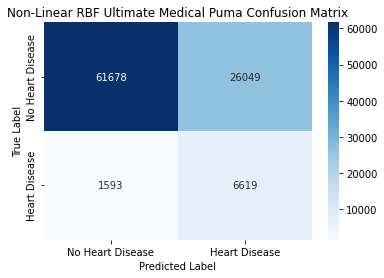


Winning Feature List:
['BMI', 'Smoking', 'AlcoholDrinking', 'Stroke', 'MentalHealth', 'Sex', 'AgeCategory', 'Diabetic', 'GenHealth', 'SleepTime', 'SkinCancer', 'Race_Black', 'Race_Hispanic']


In [8]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics
from sklearn.linear_model import SGDClassifier
from sklearn.kernel_approximation import Nystroem
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# =====================================================================
# 0. AUTO-RELOAD DATA IF KERNEL RESTARTED
# =====================================================================
if "X_scaled_values" not in locals() and "X_scaled_values" not in globals():
    print("Reloading and scaling dataset from heart_2020_cleaned.csv...")
    data = pd.read_csv("heart_2020_cleaned.csv")
    binary_cols = ['HeartDisease', 'Smoking', 'AlcoholDrinking', 'Stroke', 
                   'DiffWalking', 'PhysicalActivity', 'Asthma', 'KidneyDisease', 'SkinCancer']
    for col in binary_cols:
        data[col] = data[col].map({'Yes': 1, 'No': 0})
    data['Sex'] = data['Sex'].map({'Male': 1, 'Female': 0})
    data['Diabetic'] = data['Diabetic'].replace({'Yes': 1, 'Yes (during pregnancy)': 1, 'No': 0, 'No, borderline diabetes': 0})
    
    le = LabelEncoder()
    data['AgeCategory'] = le.fit_transform(data['AgeCategory'])
    data['GenHealth'] = le.fit_transform(data['GenHealth'])
    data = pd.get_dummies(data, columns=['Race'], drop_first=True)
    
    X = data.drop('HeartDisease', axis=1)
    y = data['HeartDisease']
    scaler = StandardScaler()
    X_scaled_values = scaler.fit_transform(X)
    data_scaled = pd.DataFrame(X_scaled_values, columns=X.columns)
    data_scaled['HeartDisease'] = y.values
    print("Data reloaded successfully! Shape:", data_scaled.shape)

# =====================================================================
# 1. NON-LINEAR RBF ULTIMATE MEDICAL PUMA OPTIMIZER
# =====================================================================
def run_rbf_medical_puma(X, y, n_pop=100, max_iter=100, epoch_length=5):
    """
    Non-Linear RBF Ultimate Medical Puma Optimizer for 300k rows.
    - Non-Linear RBF: Uses Nystroem(n_components=100) + SGDClassifier for fast curved boundaries.
    - 24 Co-Evolved Genes: 21 Features + Alpha [1e-5, 1.0] + PosWeight [1.0, 10.0] + Gamma [0.001, 10.0].
    - Decoupled Exploration: Eliminates 'black-hole' collapse toward Male Puma.
    - Precision-Aware Fitness: 45% Recall + 35% Precision + 20% Accuracy via 3-Fold Stratified CV.
    """
    n_samples, n_features = X.shape
    n_params = n_features + 3  # 21 bits + Alpha + PosWeight + Gamma
    
    # Stratified Subsample for Fast Optimization Loop (15,000 rows)
    sub_size = min(15000, n_samples)
    _, X_sub, _, y_sub = train_test_split(X, y, test_size=sub_size, random_state=42, stratify=y)
    
    def get_fitness(individual):
        # Gene 0:21 -> Binary feature bits via Sigmoid
        bits = (1 / (1 + np.exp(-np.clip(individual[:n_features], -10, 10))) > 0.5).astype(int)
        if np.sum(bits) == 0:
            bits[np.random.randint(0, n_features)] = 1
            
        # Gene 21 -> Alpha mapped to [1e-5, 1.0]
        alpha_val = 10 ** ((individual[n_features] * 0.5) - 2.5)
        alpha_val = max(1e-5, min(alpha_val, 1.0))
        
        # Gene 22 -> PosWeight mapped to [1.0, 10.0]
        pos_weight = 1.0 + (9.0 / (1.0 + np.exp(-np.clip(individual[n_features + 1], -10, 10))))
        
        # Gene 23 -> Gamma (RBF kernel curvature) mapped to [0.001, 10.0]
        gamma_val = 10 ** ((individual[n_features + 2] * 0.4) - 1.0)
        gamma_val = max(0.001, min(gamma_val, 10.0))
        
        selected_cols = np.where(bits == 1)[0]
        X_sel = X_sub[:, selected_cols]
        
        skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
        recalls, precisions, accuracies = [], [], []
        
        for train_idx, val_idx in skf.split(X_sel, y_sub):
            # 1. Non-Linear RBF Landmark Approximation (100 anchor points)
            rbf_sampler = Nystroem(kernel='rbf', gamma=gamma_val, n_components=100, random_state=42)
            X_train_rbf = rbf_sampler.fit_transform(X_sel[train_idx])
            X_val_rbf   = rbf_sampler.transform(X_sel[val_idx])
            
            # 2. Fast Linear SVM in the Non-Linear RBF Space
            clf = SGDClassifier(
                loss='hinge', penalty='l2', alpha=alpha_val,
                class_weight={0: 1.0, 1: pos_weight},
                max_iter=500, random_state=42
            )
            clf.fit(X_train_rbf, y_sub.iloc[train_idx])
            preds = clf.predict(X_val_rbf)
            
            recalls.append(metrics.recall_score(y_sub.iloc[val_idx], preds, zero_division=0))
            precisions.append(metrics.precision_score(y_sub.iloc[val_idx], preds, zero_division=0))
            accuracies.append(metrics.accuracy_score(y_sub.iloc[val_idx], preds))
            
        mean_rec  = np.mean(recalls)
        mean_prec = np.mean(precisions)
        mean_acc  = np.mean(accuracies)
        
        # Calculate F2-Score (multiplicative: 0% Recall = 0 score, Recall weighted 2x over Precision)
        mean_f2 = (5 * mean_prec * mean_rec) / max(1e-6, (4 * mean_prec) + mean_rec)
        
        # Use 80% F2-Score + 20% Recall as the medical objective
        medical_score = (0.80 * mean_f2) + (0.20 * mean_rec)
        error = 1.0 - medical_score
        penalty = 0.001 * (np.sum(bits) / n_features)
        
        return error + penalty, mean_rec, mean_prec, mean_acc, bits, alpha_val, pos_weight, gamma_val

    # Initialize Population
    population = np.random.uniform(-5, 5, size=(n_pop, n_params))
    eval_results = [get_fitness(p) for p in population]
    fitness = np.array([res[0] for res in eval_results])
    
    best_idx = np.argmin(fitness)
    male_puma = population[best_idx].copy()
    best_score = fitness[best_idx]
    
    # Phase Change Variables (Paper Table 3)
    PF1, PF2, PF3 = 0.5, 0.5, 0.3
    history_explore, history_exploit = [], []
    t_explore, t_exploit = 0, 0
    f3_explore, f3_exploit = 0.0, 0.0
    a_explore, a_exploit = 0.99, 0.99
    
    print("Starting Non-Linear RBF Ultimate Medical Puma Optimization...")
    stagnation_counter = 0
    current_phase = "BOTH"
    epoch_timer = 0
    
    def calc_hamming_diversity(pop, m_puma):
        m_bits = (1 / (1 + np.exp(-np.clip(m_puma[:n_features], -10, 10))) > 0.5).astype(int)
        all_bits = (1 / (1 + np.exp(-np.clip(pop[:, :n_features], -10, 10))) > 0.5).astype(int)
        distances = [np.sum(np.abs(all_bits[i] - m_bits)) for i in range(len(pop))]
        return np.mean(distances)

    # --- DECOUPLED EXPLORATION ---
    def run_explore(current_pop, current_fit, m_puma):
        new_pop, new_fit = current_pop.copy(), current_fit.copy()
        old_best = np.min(current_fit)
        for i in range(n_pop):
            r1, r2, r3 = np.random.choice(n_pop, 3, replace=False)
            G = 2 * np.random.rand() - 1
            # Centered on random peer r1 instead of male_puma
            Z = current_pop[r1] + G * (current_pop[r2] - current_pop[r3]) + G * (current_pop[r1] - current_pop[i])
            fit, _, _, _, _, _, _, _ = get_fitness(Z)
            if fit <= current_fit[i]:
                new_pop[i] = Z
                new_fit[i] = fit
        return new_pop, new_fit, old_best, np.min(new_fit)

    def run_exploit(current_pop, current_fit, m_puma, alpha_param):
        new_pop, new_fit = current_pop.copy(), current_fit.copy()
        old_best = np.min(current_fit)
        for i in range(n_pop):
            if np.random.rand() > 0.5:
                L = alpha_param * (2 * np.random.rand() - 1)
                Z = m_puma - np.random.rand() * np.abs(m_puma - current_pop[i]) * L
            else:
                V = alpha_param * np.random.randn(n_params)
                Z = m_puma - V * np.abs(m_puma - current_pop[i])
            fit, _, _, _, _, _, _, _ = get_fitness(Z)
            if fit <= current_fit[i]:
                new_pop[i] = Z
                new_fit[i] = fit
        return new_pop, new_fit, old_best, np.min(new_fit)

    # 4. Main Loop
    for t in range(max_iter):
        alpha_param = 2 * (1 - (t / max_iter))
        improved_this_cycle = False
        
        # --- EPOCH PHASE SELECTION LOGIC ---
        if epoch_timer == 0 and t >= 3:
            def calc_f1(hist, t_unselected):
                if not hist: return 0
                return PF1 * (abs(hist[-1]['old'] - hist[-1]['new']) / max(1, t_unselected))
            def calc_f2(hist):
                if not hist: return 0
                recent = hist[-3:]
                sum_diff = sum(abs(h['old'] - h['new']) for h in recent)
                sum_t = sum(max(1, h['t_unselected']) for h in recent)
                return PF2 * (sum_diff / max(1, sum_t))
                
            f1_exp, f1_expt = calc_f1(history_explore, t_explore), calc_f1(history_exploit, t_exploit)
            f2_exp, f2_expt = calc_f2(history_explore), calc_f2(history_exploit)
            d_explore, d_exploit = 1 - a_explore, 1 - a_exploit
            lc_explore = max(abs(history_explore[-1]['old'] - history_explore[-1]['new']) if history_explore else 0.001, 0.001)
            lc_exploit = max(abs(history_exploit[-1]['old'] - history_exploit[-1]['new']) if history_exploit else 0.001, 0.001)
            
            F_explore = (a_explore * f1_exp) + (a_explore * f2_exp) + (d_explore * lc_explore * f3_explore)
            F_exploit = (a_exploit * f1_expt) + (a_exploit * f2_expt) + (d_exploit * lc_exploit * f3_exploit)
            
            if F_exploit >= F_explore:
                current_phase = "EXPLOIT"
                a_explore = max(0.01, a_explore - 0.01)
                a_exploit = 0.99
                f3_exploit, f3_explore = 0, f3_explore + PF3
            else:
                current_phase = "EXPLORE"
                a_exploit = max(0.01, a_exploit - 0.01)
                a_explore = 0.99
                f3_explore, f3_exploit = 0, f3_exploit + PF3
                
            epoch_timer = epoch_length

        if epoch_timer > 0:
            epoch_timer -= 1

        # --- EXECUTE PHASE ---
        if current_phase == "BOTH":
            pop_exp, fit_exp, old_best_exp, new_best_exp = run_explore(population, fitness, male_puma)
            pop_expt, fit_expt, old_best_expt, new_best_expt = run_exploit(population, fitness, male_puma, alpha_param)
            combined_pop = np.vstack((pop_exp, pop_expt))
            combined_fit = np.concatenate((fit_exp, fit_expt))
            best_indices = np.argsort(combined_fit)[:n_pop]
            population, fitness = combined_pop[best_indices], combined_fit[best_indices]
            history_explore.append({'old': old_best_exp, 'new': new_best_exp, 't_unselected': t_explore})
            history_exploit.append({'old': old_best_expt, 'new': new_best_expt, 't_unselected': t_exploit})
            t_explore, t_exploit = 0, 0
        elif current_phase == "EXPLORE":
            t_exploit += 1
            population, fitness, old_best_exp, new_best_exp = run_explore(population, fitness, male_puma)
            history_explore.append({'old': old_best_exp, 'new': new_best_exp, 't_unselected': t_explore})
            t_explore = 0
        elif current_phase == "EXPLOIT":
            t_explore += 1
            population, fitness, old_best_expt, new_best_expt = run_exploit(population, fitness, male_puma, alpha_param)
            history_exploit.append({'old': old_best_expt, 'new': new_best_expt, 't_unselected': t_exploit})
            t_exploit = 0

        curr_best_idx = np.argmin(fitness)
        if fitness[curr_best_idx] < best_score:
            male_puma = population[curr_best_idx].copy()
            best_score = fitness[curr_best_idx]
            improved_this_cycle = True
            
        if not improved_this_cycle:
            stagnation_counter += 1
        else:
            stagnation_counter = 0

        div_bits = calc_hamming_diversity(population, male_puma)
            
        # --- DUAL-TRIGGER CATACLYSM WITH PHASE MEMORY RESET ---
        triggered_reason = ""
        if stagnation_counter >= 10:
            triggered_reason = f"Stagnation ({stagnation_counter} cycles)"
        elif div_bits < 1.5 and t > 5:
            triggered_reason = f"Spatial Collapse (Div={div_bits:.2f} bits < 1.5)"

        if triggered_reason:
            print(f"  [!] {triggered_reason} detected! Triggering Cataclysm + Phase Memory Reset...")
            population[0] = male_puma
            fitness[0] = best_score
            for j in range(1, n_pop):
                population[j] = np.random.uniform(-5, 5, n_params)
                fitness[j] = get_fitness(population[j])[0]
            stagnation_counter = 0
            
            history_explore.clear()
            history_exploit.clear()
            t_explore, t_exploit = 0, 0
            f3_explore, f3_exploit = 0.0, 0.0
            a_explore, a_exploit = 0.99, 0.99
            current_phase = "EXPLORE"
            epoch_timer = 4
            div_bits = calc_hamming_diversity(population, male_puma)
            
        _, cur_rec, cur_prec, cur_acc, cur_bits, cur_alpha, cur_posw, cur_gamma = get_fitness(male_puma)
        cur_f1 = 2 * (cur_prec * cur_rec) / max(1e-6, cur_prec + cur_rec)
        print(f"Cycle {t+1:02d}: Phase={current_phase:7s} (T={epoch_timer}) | Div={div_bits:4.1f} | Recall={cur_rec*100:.1f}%, Prec={cur_prec*100:.1f}%, F1={cur_f1*100:.1f}% | Feats={np.sum(cur_bits)} | Alpha={cur_alpha:.4f}, PosW={cur_posw:.2f}, Gamma={cur_gamma:.3f}")
        
    return get_fitness(male_puma)


# =====================================================================
# 2. EXECUTE OPTIMIZATION & EVALUATE ON FULL 300K DATASET
# =====================================================================
start_opt_time = time.time()
final_results = run_rbf_medical_puma(X_scaled_values, y, n_pop=100, max_iter=100, epoch_length=5)
opt_time = time.time() - start_opt_time

f_score, f_rec, f_prec, f_acc, f_bits, f_alpha, f_posw, f_gamma = final_results
f_f1 = 2 * (f_prec * f_rec) / max(1e-6, f_prec + f_rec)

selected_indices = np.where(f_bits == 1)[0]
winning_feature_names = list(data_scaled.drop('HeartDisease', axis=1).columns[f_bits == 1])

# 3. Final Evaluation on Full 300k Holdout Test Set
X_winning = X_scaled_values[:, selected_indices]
X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(
    X_winning, y, test_size=0.3, random_state=42, stratify=y
)

# Apply Optimized Non-Linear RBF Landmark Approximation to Full Dataset
final_rbf_sampler = Nystroem(kernel='rbf', gamma=f_gamma, n_components=100, random_state=42)
X_train_rbf = final_rbf_sampler.fit_transform(X_train_w)
X_test_rbf  = final_rbf_sampler.transform(X_test_w)

final_clf = SGDClassifier(
    loss='hinge', penalty='l2', alpha=f_alpha,
    class_weight={0: 1.0, 1: f_posw},
    max_iter=1000, random_state=42
)
final_clf.fit(X_train_rbf, y_train_w)
y_pred_w = final_clf.predict(X_test_rbf)

test_acc  = metrics.accuracy_score(y_test_w, y_pred_w)
test_rec  = metrics.recall_score(y_test_w, y_pred_w)
test_prec = metrics.precision_score(y_test_w, y_pred_w)
test_f1   = metrics.f1_score(y_test_w, y_pred_w)

print("\n" + "="*75)
print(" 🩺 NON-LINEAR RBF ULTIMATE MEDICAL PUMA REPORT 🩺 ")
print("="*75)
print(f"Total Optimization Time: {opt_time/60:.2f} minutes")
print(f"Features Selected:       {len(winning_feature_names)} / {X_scaled_values.shape[1]}")
print(f"Optimized Alpha:         {f_alpha:.6f}")
print(f"Optimized Class Weight:  No HeartDisease = 1.0, HeartDisease = {f_posw:.2f}")
print(f"Optimized RBF Gamma:     {f_gamma:.4f}  (Non-Linear Curvature)")
print("-" * 75)
print(f"Test Accuracy:  {test_acc*100:.2f}%  (Overall correctness)")
print(f"Test Recall:    {test_rec*100:.2f}%  <-- #1 MEDICAL PRIORITY")
print(f"Test Precision: {test_prec*100:.2f}%  <-- NON-LINEAR ENHANCED")
print(f"Test F1-Score:  {test_f1*100:.2f}%  <-- HARMONIC BALANCE")
print("="*75)

cm = metrics.confusion_matrix(y_test_w, y_pred_w)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Heart Disease', 'Heart Disease'],
            yticklabels=['No Heart Disease', 'Heart Disease'])
plt.title('Non-Linear RBF Ultimate Medical Puma Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

print("\nWinning Feature List:")
print(winning_feature_names)